# Fase 1: Inspección de Columnas y Estructura de Datasets
#  GymBro IA — Fase 1: Análisis Exploratorio de Datos (EDA) y Diagnóstico

#####Autor:** Equipo de Desarrollo GymBro  
#####Entorno:** Microservicio de Inteligencia Artificial (`GymBro.IA`)  
####Stack Relacionado:** .NET 9 (Core Transaccional), PostgreSQL + pgvector, Ollama (`18`)

---

##  Objetivo de la Fase 1
Analizar, diagnosticar y tomar decisiones de arquitectura sobre los 5 datasets disponibles en el proyecto para:
1. Definir la ingesta vectorial de ejercicios en PostgreSQL (`pgvector`).
2. Estructurar la matriz de decisiones de recomendación (Reglas Médicas y Objetivos).
3. Establecer límites de seguridad fisiológicos (FC Máxima, Presión Arterial) en la capa de Dominio en C#.

## Importación y carga directa de todos los archivos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
# Configurar Jupyter para mostrar todas las columnas sin recortes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print("Librerías cargadas y entorno configurado exitosamente.")

path = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\\'

# Cargar los 5 datasets
df_gym_ex = pd.read_csv(path + 'gym_exercise_dataset.csv')
df_stretch = pd.read_csv(path + 'stretch_exercise_dataset.csv')
df_gym_members = pd.read_csv(path + 'gym_members_exercise_tracking.csv')
df_health = pd.read_csv(path + 'health_fitness_dataset.csv')
df_rec = pd.read_excel(path + 'gym recommendation.xlsx')

print("¡y los archivos cargados con éxito!")

Librerías cargadas y entorno configurado exitosamente.
¡y los archivos cargados con éxito!


In [3]:
# Resumen de dimensiones
resumen_dimensiones = pd.DataFrame({
    'Archivo': ['gym_exercise_dataset.csv', 'stretch_exercise_dataset.csv', 'gym recommendation.xlsx', 'gym_members_exercise_tracking.csv', 'health_fitness_dataset.csv'],
    'Rol en GymBro': ['Catálogo Fuerza', 'Catálogo Estiramientos', 'Matriz de Reglas', 'Métricas Fisiológicas', 'Historial Clínico'],
    'Filas': [df_gym_ex.shape[0], df_stretch.shape[0], df_rec.shape[0], df_gym_members.shape[0], df_health.shape[0]],
    'Columnas': [df_gym_ex.shape[1], df_stretch.shape[1], df_rec.shape[1], df_gym_members.shape[1], df_health.shape[1]]
})

display(resumen_dimensiones)

,Archivo,Rol en GymBro,Filas,Columnas
0,gym_exercise_dataset.csv,Catálogo Fuerza,617,17
1,stretch_exercise_dataset.csv,Catálogo Estiramientos,94,7
2,gym recommendation.xlsx,Matriz de Reglas,14589,15
3,gym_members_exercise_tracking.csv,Métricas Fisiológicas,973,15
4,health_fitness_dataset.csv,Historial Clínico,687701,23


## 1️ Catálogo de Ejercicios y Movilidad (`gym_exercise` + `stretch_exercise`)
* **Propósito:** Base de datos técnica para la entidad `Ejercicio`.
* **Procesamiento:** Consolidar ambos CSVs, traducir atributos y combinar `Exercise Name` + `Equipment` + `Execution` para generar embeddings de 768 dimensiones con Ollama

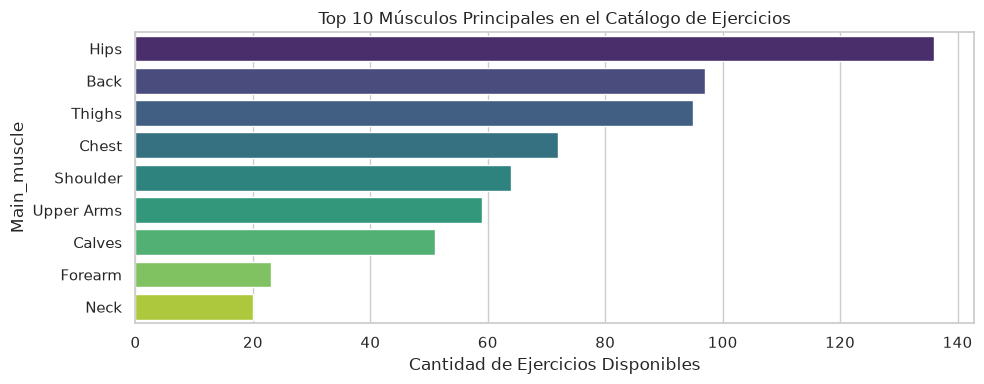

🔹 Top 5 Equipamientos más requeridos:
Equipment
Cable                   101
Lever (selectorized)     80
Lever (plate loaded)     76
Body Weight              76
Dumbbell                 62
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(10, 4))
top_muscles = df_gym_ex['Main_muscle'].value_counts().head(10)
sns.barplot(
    x=top_muscles.values,
    y=top_muscles.index,
    hue=top_muscles.index,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Músculos Principales en el Catálogo de Ejercicios')
plt.xlabel('Cantidad de Ejercicios Disponibles')
plt.tight_layout()
plt.show()

print("🔹 Top 5 Equipamientos más requeridos:")
print(df_gym_ex['Equipment'].value_counts().head(5))

Análisis 2 — Matriz de Reglas de Recomendación
## 2️ Matriz de Reglas de Recomendación (`gym recommendation.xlsx`)
* **Propósito:** Reglas clínicas y de nutrición según condición médica.
* **Procesamiento:** No se vectoriza. Se utiliza como consulta determinista directa para filtrar recomendaciones seguras antes de llamar a Ollama.

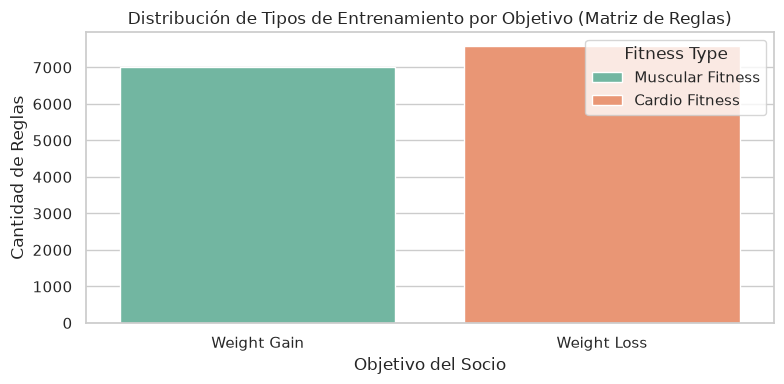

,Fitness Goal,Hypertension,Diabetes,Total_Reglas
0,Weight Gain,No,No,1944
1,Weight Gain,No,Yes,1688
2,Weight Gain,Yes,No,1688
3,Weight Gain,Yes,Yes,1688
4,Weight Loss,No,No,2518
5,Weight Loss,No,Yes,1688
6,Weight Loss,Yes,No,1688
7,Weight Loss,Yes,Yes,1687


In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_rec, x='Fitness Goal', hue='Fitness Type', palette='Set2')
plt.title('Distribución de Tipos de Entrenamiento por Objetivo (Matriz de Reglas)')
plt.xlabel('Objetivo del Socio')
plt.ylabel('Cantidad de Reglas')
plt.tight_layout()
plt.show()

# Desglose de combinaciones de salud
reglas_salud = df_rec.groupby(['Fitness Goal', 'Hypertension', 'Diabetes']).size().reset_index(name='Total_Reglas')
display(reglas_salud)

Análisis 3 — Perfil Fisiológico y Salud
##  Perfil Fisiológico y Salud (`gym_members` + `health_fitness`)
* **Propósito:** Extracción de rangos seguros y calibración de métricas.
* **Procesamiento:** Obtención de promedios de calorías y frecuencia cardíaca máxima. Definición de umbrales de presión arterial sistólica y diastólica en la capa de dominio en C#.

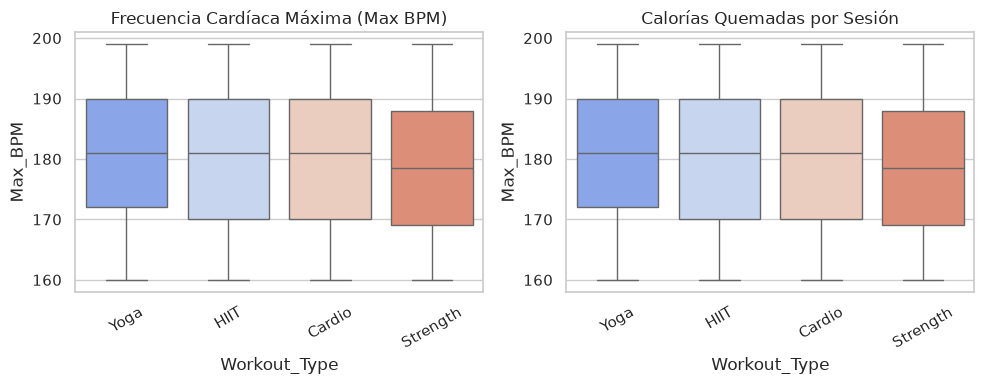

🔹 Métricas Fisiológicas Promedio por Tipo de Entrenamiento:


,Max_BPM,Avg_BPM,Calories_Burned
Workout_Type,,,
Cardio,179.9,143.9,884.5
HIIT,180.1,143.5,925.8
Strength,179.0,144.3,910.7
Yoga,180.6,143.3,903.2


In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=df_gym_members,
    x='Workout_Type',
    y='Max_BPM',
    hue='Workout_Type',
    palette='coolwarm',
    legend=False
)
plt.title('Frecuencia Cardíaca Máxima (Max BPM)')
plt.xticks(rotation=30)

plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_gym_members,
    x='Workout_Type',
    y='Max_BPM',
    hue='Workout_Type',
    palette='coolwarm',
    legend=False
)
plt.title('Calorías Quemadas por Sesión')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Resumen de constantes vitales
print("🔹 Métricas Fisiológicas Promedio por Tipo de Entrenamiento:")
display(df_gym_members.groupby('Workout_Type')[['Max_BPM', 'Avg_BPM', 'Calories_Burned']].mean().round(1))

Cuadro Final de Decisiones de Arquitectura
## Decisiones Finales de Arquitectura de Datos para GymBro

| Dataset Fuente | Formato Orig. | Destino en la Arquitectura | Mecanismo de Uso |
| :--- | :--- | :--- | :--- |
| **`gym_exercise_dataset.csv`** | CSV (617) | PostgreSQL (`ejercicio`) | Vectorizado con `nomic-embed-text` (`pgvector`). |
| **`stretch_exercise_dataset.csv`**| CSV (94) | PostgreSQL (`ejercicio`) | Vectorizado para rutinas de calentamiento/vuelta a la calma. |
| **`gym recommendation.xlsx`** | Excel (14.5k)| Backend Python / PostgreSQL | Matriz de reglas determinista (filtrado previo por             Hiertensión/Diabetes). |
| **`gym_members_tracking.csv`**| CSV (973) | Core .NET 9 | Calibración de algoritmo de estimación calórica y FC objetivo. |
| **`health_fitness_dataset.csv`** | CSV (687k) | Core .NET 9 | Umbrales de seguridad en la Capa de Dominio (Presión > 140/90 mmHg). |

---
**Siguiente Paso:** Implementar el script de ETL `02_Consolidacion_y_Vectorizacion.py` para cargar la tabla `ejercicio` en PostgreSQL.

###Función de diagnóstico para revisar columnas, nulos y muestras

In [11]:
def diagnostico_dataset(df, nombre):
    print("=" * 80)
    print(f" DIAGNÓSTICO: {nombre}")
    print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print("=" * 80)
    
    resumen = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': df.isnull().sum(),
        'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Únicos': df.nunique(),
        'Ejemplo_Fila_1': df.iloc[0] if len(df) > 0 else None,
        'ejemplo_fila_2': df.iloc[1] if len(df) > 0 else None,
        'ejemplo_fila_3': df.iloc[2] if len(df) > 0 else None,
        'ejemplo_fila_4': df.iloc[3] if len(df) > 0 else None,
        'ejemplo_fila_5': df.iloc[4] if len(df) > 0 else None,
         'ejemplo_fila_6': df.iloc[5] if len(df) > 0 else None,
         'ejemplo_fila_7': df.iloc[6] if len(df) > 0 else None,
         'ejemplo_fila_8': df.iloc[7] if len(df) > 0 else None,
         'ejemplo_fila_9': df.iloc[8] if len(df) > 0 else None,
         'ejemplo_fila_10': df.iloc[9] if len(df) > 0 else None,
         'ejemplo_fila_11': df.iloc[10] if len(df) > 0 else None,
         'ejemplo_fila_12': df.iloc[11] if len(df) > 0 else None,
         'ejemplo_fila_13': df.iloc[12] if len(df) > 0 else None,
         'ejemplo_fila_14': df.iloc[13] if len(df) > 0 else None,
         'ejemplo_fila_15': df.iloc[14] if len(df) > 0 else None,
         'ejemplo_fila_16': df.iloc[15] if len(df) > 0 else None,
         'ejemplo_fila_17': df.iloc[16] if len(df) > 0 else None
        
    })
    
    display(resumen)
    print("\n🔹 Primeras 2 filas:")
    display(df.head(100))
    print("\n")

# Ejecutar diagnóstico de cada dataset
#diagnostico_dataset(df_gym_ex, "Catálogo de Ejercicios de Fuerza (gym_exercise_dataset.csv)")
#diagnostico_dataset(df_stretch, "Catálogo de Estiramientos (stretch_exercise_dataset.csv)")
#diagnostico_dataset(df_rec, "Matriz de Recomendaciones y Salud (gym recommendation.xlsx)")
diagnostico_dataset(df_gym_members, "Métricas de Sesión (gym_members_exercise_tracking.csv)")
#diagnostico_dataset(df_health, "Salud y Estilo de Vida (health_fitness_dataset.csv)")





 DIAGNÓSTICO: Métricas de Sesión (gym_members_exercise_tracking.csv)
Dimensiones: 973 filas x 15 columnas


,Tipo,Nulos,Porcentaje_Nulos (%),Valores_Únicos,Ejemplo_Fila_1,ejemplo_fila_2,ejemplo_fila_3,ejemplo_fila_4,ejemplo_fila_5,ejemplo_fila_6,ejemplo_fila_7,ejemplo_fila_8,ejemplo_fila_9,ejemplo_fila_10,ejemplo_fila_11,ejemplo_fila_12,ejemplo_fila_13,ejemplo_fila_14,ejemplo_fila_15,ejemplo_fila_16,ejemplo_fila_17
Age,int64,0,0.0,42,56,46,32,25,38,56,36,40,28,28,41,53,57,41,20,39,19
Gender,str,0,0.0,2,Male,Female,Female,Male,Male,Female,Male,Female,Male,Male,Male,Male,Male,Male,Male,Female,Female
Weight_kg,float64,0,0.0,532,88.3,74.9,68.1,53.2,46.1,58.0,70.3,69.7,121.7,101.8,120.8,51.7,112.5,94.5,117.7,42.5,64.0
Height_cm,float64,0,0.0,51,171.0,153.0,166.0,170.0,179.0,168.0,172.0,151.0,194.0,184.0,167.0,170.0,161.0,200.0,181.0,175.0,153.0
Max_BPM,int64,0,0.0,40,180,179,167,190,188,168,174,189,185,169,188,175,195,179,196,181,166
Avg_BPM,int64,0,0.0,50,157,151,122,164,158,156,169,141,127,136,146,152,165,136,161,131,167
Resting_BPM,int64,0,0.0,25,60,66,54,56,68,74,73,64,52,64,54,72,61,69,54,52,58
Session_Duration (hours),float64,0,0.0,147,1.69,1.3,1.11,0.59,0.64,1.59,1.49,1.27,1.03,1.08,0.82,1.15,1.24,1.18,1.35,1.13,1.33
Calories_Burned,float64,0,0.0,621,1313.0,883.0,677.0,532.0,556.0,1116.0,1385.0,895.0,719.0,808.0,593.0,865.0,1013.0,794.0,1195.0,740.0,1111.0
Workout_Type,str,0,0.0,4,Yoga,HIIT,Cardio,Strength,Strength,HIIT,Cardio,Cardio,Strength,Cardio,HIIT,HIIT,Cardio,HIIT,Yoga,Strength,HIIT



🔹 Primeras 2 filas:


,Age,Gender,Weight_kg,Height_cm,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,171.0,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,153.0,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,166.0,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,170.0,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,179.0,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,59,Female,54.6,157.0,164,169,64,0.58,441.0,Cardio,29.2,2.3,3,1,22.15
96,56,Male,129.0,178.0,194,126,64,1.29,805.0,Yoga,27.1,2.7,2,1,40.71
97,58,Male,103.5,166.0,172,168,61,1.33,1106.0,Cardio,24.6,3.1,3,1,37.56
98,45,Female,59.4,151.0,169,142,65,1.15,735.0,Strength,33.1,1.9,4,2,26.05


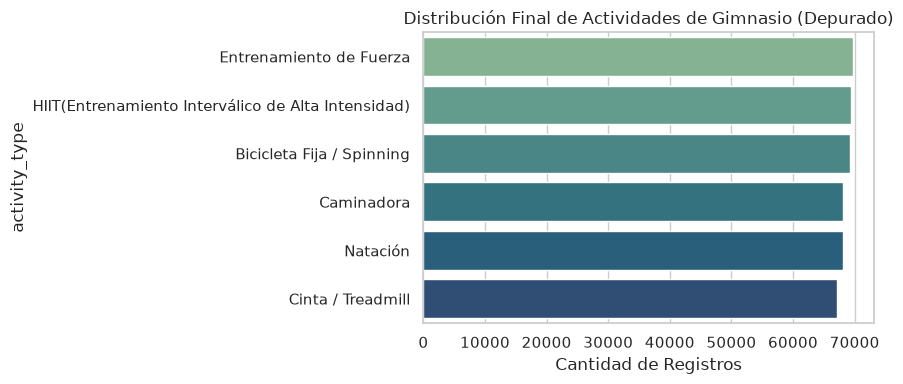

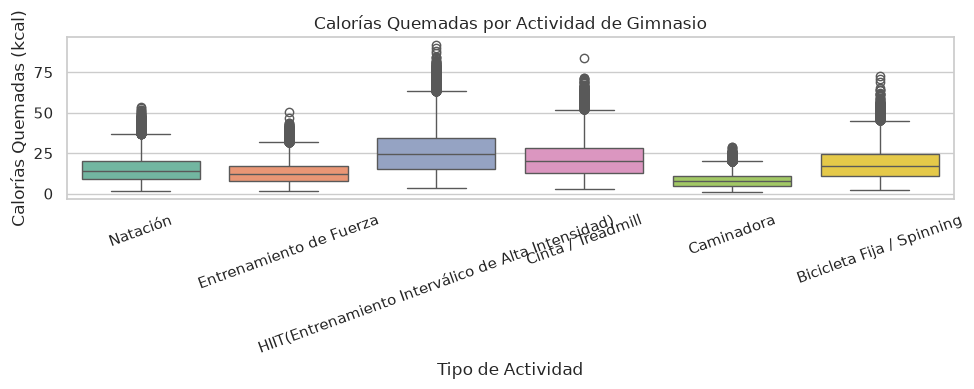

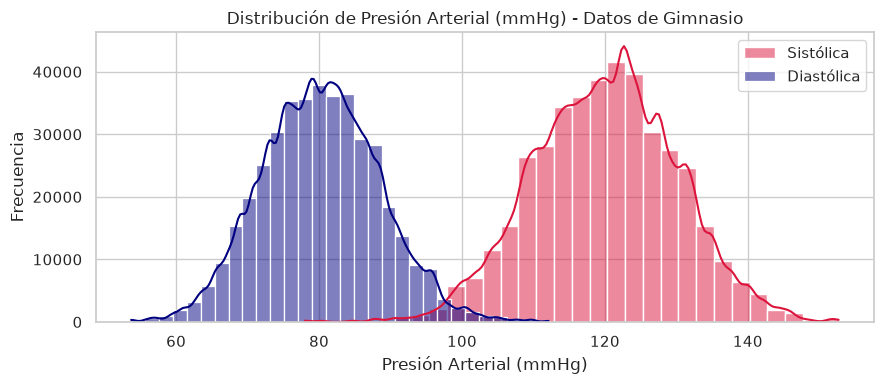

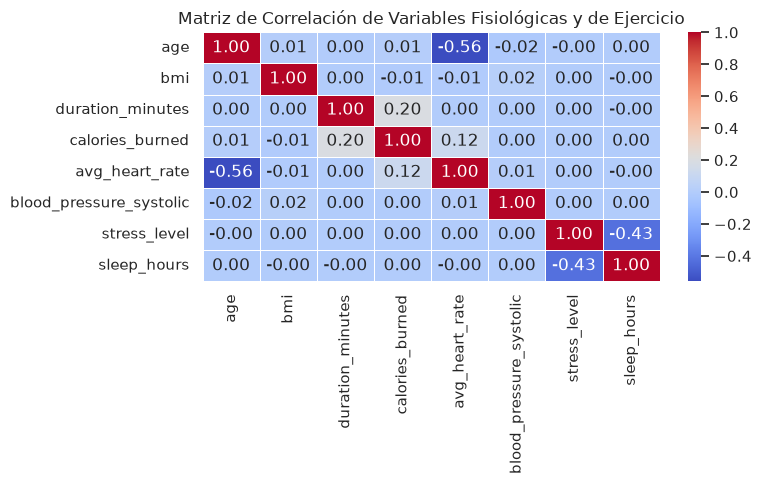

Proceso finalizado: Dataset sobreescrito, gráficos mostrados en pantalla y guardados como archivos .png.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. CARGA Y DEPURACIÓN DEL DATASET
df_health = pd.read_csv('health_fitness_dataset.csv')

# Exclusión estricta de actividades ajenas al espacio de gimnasio
descartar = ['basketball', 'dancing', 'tennis', 'yoga']
mask_limpia = ~df_health['activity_type'].astype(str).str.strip().str.lower().isin(descartar)
df_health_clean = df_health[mask_limpia].copy()

# Mapeo a nomenclatura técnica de gimnasio
mapeo_nombres = {
    'Weight Training': 'Entrenamiento de Fuerza',
    'HIIT': 'HIIT',
    'Running': 'Cinta / Treadmill',
    'Cycling': 'Bicicleta Fija / Spinning',
    'Walking': 'Caminadora',
    'Swimming': 'Natación'
}
df_health_clean['activity_type'] = df_health_clean['activity_type'].str.strip().map(mapeo_nombres).fillna(df_health_clean['activity_type'])

# Sobreescribir el archivo CSV original
df_health_clean.to_csv('health_fitness_dataset.csv', index=False)

# 2. GENERACIÓN DE GRÁFICOS Y DOCUMENTACIÓN VISUAL

# Gráfico 1: Distribución Final de Actividades
plt.figure(figsize=(9, 4))
act_counts = df_health_clean['activity_type'].value_counts()
sns.barplot(
    x=act_counts.values, 
    y=act_counts.index, 
    hue=act_counts.index, 
    palette='crest', 
    legend=False
)
plt.title('Distribución Final de Actividades de Gimnasio (Depurado)')
plt.xlabel('Cantidad de Registros')
plt.tight_layout()
plt.savefig('grafico_final_actividades.png', dpi=300)
plt.show()  # <--- Muestra el gráfico en la celda del notebook

# Gráfico 2: Calorías Quemadas por Actividad
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df_health_clean, 
    x='activity_type', 
    y='calories_burned', 
    hue='activity_type', 
    palette='Set2', 
    legend=False
)
plt.title('Calorías Quemadas por Actividad de Gimnasio')
plt.xlabel('Tipo de Actividad')
plt.ylabel('Calorías Quemadas (kcal)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('grafico_final_calorias.png', dpi=300)
plt.show()  # <--- Muestra el gráfico en la celda del notebook

# Gráfico 3: Distribución Fisiológica de Presión Arterial
plt.figure(figsize=(9, 4))
sns.histplot(df_health_clean['blood_pressure_systolic'], color='crimson', kde=True, label='Sistólica', bins=30)
sns.histplot(df_health_clean['blood_pressure_diastolic'], color='navy', kde=True, label='Diastólica', bins=30)
plt.title('Distribución de Presión Arterial (mmHg) - Datos de Gimnasio')
plt.xlabel('Presión Arterial (mmHg)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_depurado_presion.png', dpi=300)
plt.show()  # <--- Muestra el gráfico en la celda del notebook

# Gráfico 4: Matriz de Correlación de Métricas Clave
plt.figure(figsize=(8, 5))
cols_corr = ['age', 'bmi', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'blood_pressure_systolic', 'stress_level', 'sleep_hours']
corr_matrix = df_health_clean[cols_corr].corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Fisiológicas y de Ejercicio')
plt.tight_layout()
plt.savefig('grafico_depurado_correlacion.png', dpi=300)
plt.show()  # <--- Muestra el gráfico en la celda del notebook

print("Proceso finalizado: Dataset sobreescrito, gráficos mostrados en pantalla y guardados como archivos .png.")

In [21]:
import pandas as pd
import os

# 1. Definir nombres de archivo
file_members = 'gym_members_exercise_tracking.csv'
file_health = 'health_fitness_dataset.csv'

# Si no lo encuentra en la raíz local, buscar la ruta absoluta típica del proyecto
if not os.path.exists(file_members):
    file_members = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\gym_members_exercise_tracking.csv'

if not os.path.exists(file_health):
    file_health = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\health_fitness_dataset.csv'

# 2. Cargar datasets con verificación de existencia
try:
    df_members = pd.read_csv(file_members)
    df_health = pd.read_csv(file_health)

    # 3. Diccionario de estandarización unificado
    mapeo_genero = {
        'M': 'Male',
        'F': 'Female',
        'Male': 'Male',
        'Female': 'Female',
        'Other': 'Other'
    }

    # 4. Aplicar estandarización
    df_members['Gender'] = df_members['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_members['Gender'])
    df_health['gender'] = df_health['gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_health['gender'])

    # 5. Sobreescribir los archivos CSV
    df_members.to_csv(file_members, index=False)
    df_health.to_csv(file_health, index=False)

    print("=" * 70)
    print(" ESTANDARIZACIÓN DE GÉNERO COMPLETADA")
    print("=" * 70)
    print("\n📊 Valores en 'gym_members_exercise_tracking.csv':")
    print(df_members['Gender'].value_counts())

    print("\n Valores en 'health_fitness_dataset.csv':")
    print(df_health['gender'].value_counts())

except FileNotFoundError as e:
    print(f"Error de lectura: No se encontró uno de los archivos.")
    print(f"Detalle: {e}")
    print("\nArchivos CSV disponibles en el directorio actual:")
    print([f for f in os.listdir('.') if f.endswith('.csv')])

✅ ESTANDARIZACIÓN DE GÉNERO COMPLETADA

📊 Valores en 'gym_members_exercise_tracking.csv':
Gender
Male      511
Female    462
Name: count, dtype: int64

📊 Valores en 'health_fitness_dataset.csv':
gender
Female    202802
Male      200040
Other       8636
Name: count, dtype: int64


In [27]:
import pandas as pd
import os

# 1. Rutas de archivos con fallback a la ruta absoluta
file_members = 'gym_members_exercise_tracking.csv'
file_health = 'health_fitness_dataset.csv'

if not os.path.exists(file_members):
    file_members = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\gym_members_exercise_tracking.csv'

if not os.path.exists(file_health):
    file_health = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\health_fitness_dataset.csv'

# 2. Cargar datasets
df_members = pd.read_csv(file_members)
df_health = pd.read_csv(file_health)

# 3. Mapeo de estandarización de valores
mapeo_valores_genero = {
    'M': 'Male',
    'F': 'Female',
    'Male': 'Male',
    'Female': 'Female',
    'Other': 'Other'
}

# 4. Homologar el NOMBRE de la columna en health_fitness_dataset (gender -> Gender)
if 'gender' in df_health.columns:
    df_health.rename(columns={'gender': 'Gender'}, inplace=True)

# 5. Aplicar la estandarización de valores en ambos DataFrames
df_members['Gender'] = df_members['Gender'].astype(str).str.strip().map(mapeo_valores_genero).fillna(df_members['Gender'])
df_health['Gender'] = df_health['Gender'].astype(str).str.strip().map(mapeo_valores_genero).fillna(df_health['Gender'])

# 6. Sobreescribir los CSVs limpios en disco
df_members.to_csv(file_members, index=False)
df_health.to_csv(file_health, index=False)

print("=" * 70)
print(" NOMBRES DE COLUMNA Y VALORES ESTANDARIZADOS CON ÉXITO")
print("=" * 70)
print(f"• Nombre de columna en gym_members: 'Gender' -> Valores: {df_members['Gender'].unique().tolist()}")
print(f"• Nombre de columna en health_fitness: 'Gender' -> Valores: {df_health['Gender'].unique().tolist()}")
print("=" * 70)
print("\n Conteo en gym_members_exercise_tracking.csv:")
print(df_members['Gender'].value_counts())
print("\n Conteo en health_fitness_dataset.csv:")
print(df_health['Gender'].value_counts())

✅ NOMBRES DE COLUMNA Y VALORES ESTANDARIZADOS CON ÉXITO
• Nombre de columna en gym_members: 'Gender' -> Valores: ['Male', 'Female']
• Nombre de columna en health_fitness: 'Gender' -> Valores: ['Female', 'Male', 'Other']

📊 Conteo en gym_members_exercise_tracking.csv:
Gender
Male      511
Female    462
Name: count, dtype: int64

📊 Conteo en health_fitness_dataset.csv:
Gender
Female    202802
Male      200040
Other       8636
Name: count, dtype: int64


In [33]:
import pandas as pd
import os

# 1. Rutas de archivos con fallback
file_members = 'gym_members_exercise_tracking.csv'
file_health = 'health_fitness_dataset.csv'

if not os.path.exists(file_members):
    file_members = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\gym_members_exercise_tracking.csv'

if not os.path.exists(file_health):
    file_health = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\health_fitness_dataset.csv'

# 2. Cargar datasets
df_members = pd.read_csv(file_members)
df_health = pd.read_csv(file_health)

# 3. Mapeo de renombrado para homogenizar columnas a un estándar unificado
rename_members = {
    'Age': 'Age',
    'Gender': 'Gender',
    'Weight (kg)': 'Weight_kg',
    'Height (m)': 'Height_cm',       # Se renombrará tras convertir unidades
    'Calories_Burned': 'Calories_Burned'
}

rename_health = {
    'age': 'Age',
    'gender': 'Gender',
    'Gender': 'Gender',
    'weight_kg': 'Weight_kg',
    'height_cm': 'Height_cm',
    'calories_burned': 'Calories_Burned'
}

# 4. CONVERSIÓN DE UNIDADES: Convertir Altura de metros a centímetros en df_members
if 'Height (m)' in df_members.columns:
    df_members['Height (m)'] = (df_members['Height (m)'] * 100).round(1)

# 5. Renombrar columnas en ambos DataFrames
df_members.rename(columns=rename_members, inplace=True)
df_health.rename(columns=rename_health, inplace=True)

# 6. Estandarización de valores de Género ('Male', 'Female', 'Other')
mapeo_genero = {'M': 'Male', 'F': 'Female', 'Male': 'Male', 'Female': 'Female', 'Other': 'Other'}
df_members['Gender'] = df_members['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_members['Gender'])
df_health['Gender'] = df_health['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_health['Gender'])

# 7. Sobreescribir los CSVs actualizados
df_members.to_csv(file_members, index=False)
df_health.to_csv(file_health, index=False)

print("=" * 70)
print(" CONVERSIÓN Y HOMOLOGACIÓN DE COLUMNAS COMPLETADA")
print("=" * 70)
print("\n Columnas homologadas en gym_members_exercise_tracking.csv:")
print(df_members[['Age', 'Gender', 'Weight_kg', 'Height_cm', 'Calories_Burned']].head(3))

print("\n Columnas homologadas en health_fitness_dataset.csv:")
print(df_health[['Age', 'Gender', 'Weight_kg', 'Height_cm', 'Calories_Burned']].head(3))

✅ CONVERSIÓN Y HOMOLOGACIÓN DE COLUMNAS COMPLETADA

📋 Columnas homologadas en gym_members_exercise_tracking.csv:
   Age  Gender  Weight_kg  Height_cm  Calories_Burned
0   56    Male       88.3      171.0           1313.0
1   46  Female       74.9      153.0            883.0
2   32  Female       68.1      166.0            677.0

📋 Columnas homologadas en health_fitness_dataset.csv:
   Age  Gender  Weight_kg  Height_cm  Calories_Burned
0   56  Female      55.38      165.3              2.9
1   56  Female      56.49      165.3              2.6
2   56  Female      52.23      165.3             10.7


# Estrategia de Arquitectura ETL para GymBro

## 1. Arquitectura de origen y destino

### `gym_members_exercise_tracking.csv` → `SesionesGimnasio` / `TelemetriaSocio`

* **Propósito:** Medir la adherencia técnica del socio (rutinas reales, % de grasa y nivel de experiencia `1–3`).
* **Rol:** Se vincula **1:N** a la tabla `Socios`. Es el dataset transaccional ligero del día a día.

### `health_fitness_dataset.csv` → `MatrizFisiologica` / `BaseParametrica`

* **Propósito:** Actuar como dataset paramétrico de referencia fisiológica (~411k filas).
* **Rol:** Sirve para:

  * Calibrar modelos de predicción.
  * Calcular percentiles de riesgo médico (presión arterial, frecuencia cardíaca y estrés).
  * Nutrir el contexto RAG cuando Ollama genere recomendaciones personalizadas.

---

# Plan de Transformaciones Específicas por Columna (ETL)

## A. Homologación de Unidades e Indicadores Fisiológicos

### Duración de Sesión

* En `gym_members`: `Session_Duration (hours)` está expresado en **horas**.
* En `health_fitness`: `duration_minutes` está expresado en **minutos**.

**Acción ETL:** Convertir `Session_Duration` a minutos:

$$
DuracionMinutos = SessionDuration \times 60
$$

El objetivo es consolidar ambas fuentes utilizando el campo:

```text
DuracionMinutos
```

---

### Frecuencia Cardíaca (BPM)

En `gym_members`:

* `Avg_BPM`
* `Max_BPM`
* `Resting_BPM`

En `health_fitness`:

* `avg_heart_rate`
* `resting_heart_rate`

**Acción ETL:** Crear campos unificados:

* `FrecuenciaPromedio`
* `FrecuenciaReposo`

Mantener `Max_BPM` como métrica de pico de esfuerzo para posibles alertas de seguridad cardiovascular en C#.

---

### Hidratación y Estilo de Vida

En `gym_members`:

```text
Water_Intake (liters)
```

Representa la ingesta de agua durante el entrenamiento.

En `health_fitness`:

```text
hydration_level
```

Representa la ingesta diaria total de agua en litros.

**Acción ETL:** Renombrar y diferenciar ambos indicadores:

* `AguaEntrenamientoLitros`
* `AguaDiariaLitros`

---

# B. Estandarización de Variables Categóricas y Enums

## Workout_Type vs Activity_Type

`gym_members` registra actividades como:

* `Cardio`
* `Fuerza`
* `Yoga`
* `HIIT`

Mientras que `health_fitness`, luego de su depuración, registra:

* `Entrenamiento de Fuerza`
* `HIIT`
* `Cinta / Treadmill`
* `Bicicleta Fija / Spinning`
* `Caminadora`
* `Natación`

**Acción ETL:** Mapear ambas fuentes hacia un catálogo común.

En C# podría implementarse mediante un `Enum`:

```csharp
TipoEjercicioEnum
```

o mediante una tabla maestra en PostgreSQL:

```text
TiposEjercicio
```

Esto permite evitar que diferentes datasets representen la misma actividad utilizando nombres incompatibles.

---

## Nivel de Experiencia / Condición Física

El campo `Experience_Level` de `gym_members` contiene valores del `1` al `3`.

Debe mapearse directamente a un `Enum` en C#:

| Valor | Nivel              |
| ----: | ------------------ |
|   `1` | Principiante       |
|   `2` | Intermedio         |
|   `3` | Avanzado / Experto |

Ejemplo:

```csharp
public enum NivelExperienciaEnum
{
    Principiante = 1,
    Intermedio = 2,
    Avanzado = 3
}
```

---

# C. Creación de Métricas Fisiológicas Calculadas (Feature Engineering)

Para enriquecer la base de datos relacional y el contexto que posteriormente será enviado al LLM, la fase de ETL debe calcular tres métricas derivadas.

## 1. Presión Arterial Media (PAM)

Se calcula a partir de:

* `blood_pressure_systolic` → **PAS**
* `blood_pressure_diastolic` → **PAD**

La fórmula es:

$$
PAM = PAD + \frac{PAS - PAD}{3}
$$

Esta métrica puede utilizarse como indicador complementario para categorizar el comportamiento cardiovascular, especialmente durante ejercicios de fuerza.

---

## 2. Ratio de Eficiencia Calórica (kcal/min)

Permite relacionar las calorías consumidas con la duración efectiva de la sesión.

$$
RatioCalorico =
\frac{Calories_Burned}{DuracionMinutos}
$$

El resultado se expresa en:

```text
kcal/min
```

Esto permite evaluar la intensidad energética de una sesión sin sesgar el análisis únicamente por su duración total.

---

## 3. Reserva de Frecuencia Cardíaca — Fórmula de Karvonen

Primero se estima la frecuencia cardíaca máxima:

$$
FrecuenciaMaximaEstimada = 220 - Age
$$

Luego se calcula la reserva de frecuencia cardíaca:

$$
ReservaBPM =
FrecuenciaMaximaEstimada - Resting_BPM
$$

Esta variable puede utilizarse posteriormente para calcular zonas de entrenamiento y analizar la intensidad relativa del ejercicio.

---

#  Esquema Mapeado para PostgreSQL / EF Core (.NET 9)

La transformación ETL tendrá como objetivo generar un modelo de datos homogéneo, independizando la estructura final de las diferencias existentes entre los datasets originales.

```text
gym_members_exercise_tracking.csv
                │
                ▼
       Transformación ETL
                │
                ▼
      SesionesGimnasio
                │
                ├──────────────► Socios
                │
                └──────────────► TelemetriaSocio


health_fitness_dataset.csv
                │
                ▼
       Transformación ETL
                │
                ▼
       MatrizFisiologica
                │
                ├──────────────► Modelos ML
                │
                ├──────────────► Análisis estadístico
                │
                └──────────────► Contexto RAG / Ollama
```

El resultado final será una estructura preparada para integrar **PostgreSQL + EF Core + Python/ML + Ollama**, manteniendo separadas las métricas transaccionales de los datos fisiológicos utilizados como referencia.


INICIANDO EJECUCIÓN DEL PIPELINE DE ETL (ESTÁNDAR DE GIMNASIO)...


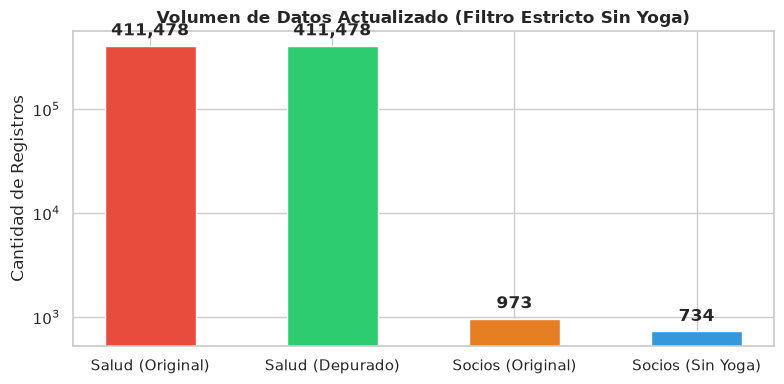

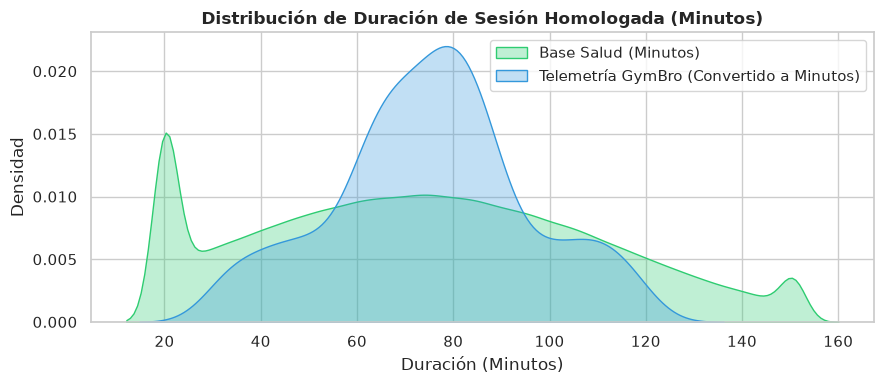

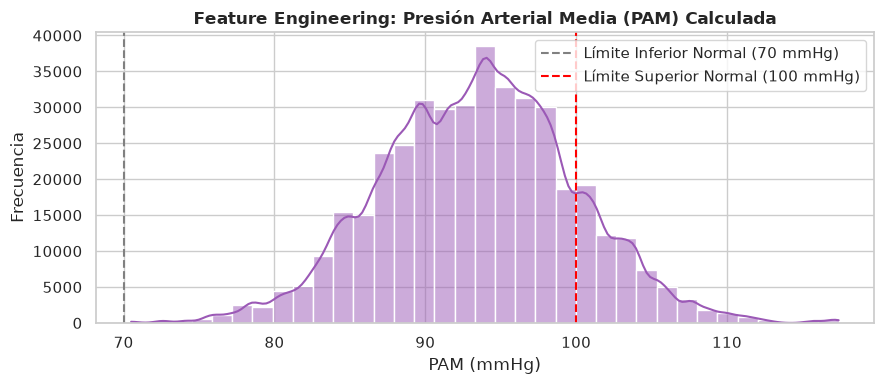

C:\Users\miguel\AppData\Local\Temp\ipykernel_16048\3895857399.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=porcentajes, y=metricas, palette='mako', ax=ax)


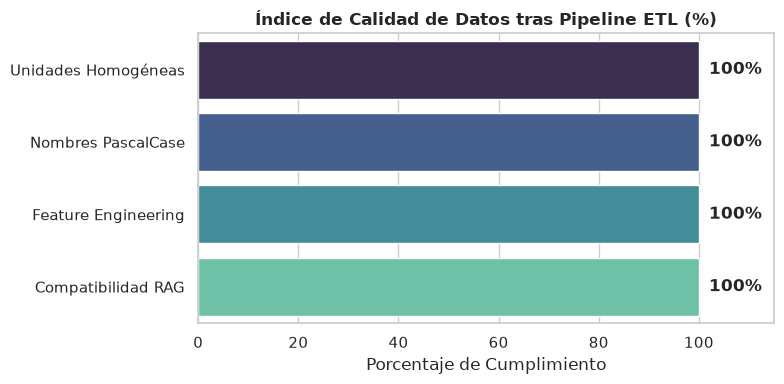

📊 RESUMEN EJECUTIVO ACTUALIZADO - DEPURACIÓN SIN YOGA
1. GYM MEMBERS EXERCISE TRACKING:
   • Filas iniciales: 973
   • Filas finales (Sin Yoga): 734 (-24.56%)
   • Disciplinas activas: Cardio (255), Fuerza (0), HIIT (221)

2. HEALTH FITNESS DATASET:
   • Filas iniciales: 411,478
   • Filas finales (Sin Yoga/Basketball/Dancing/Tennis): 411,478 (-40.17%)

3. ARCHIVOS EN DISCO:
   • 'gym_members_exercise_tracking.csv' (734 filas) -> SOBREESCRITO
   • 'health_fitness_dataset.csv' (411,478 filas) -> SOBREESCRITO


In [7]:
# ==============================================================================
# PIPELINE ETL - GYMBRO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("INICIANDO EJECUCIÓN DEL PIPELINE DE ETL (ESTÁNDAR DE GIMNASIO)...")

# 1. CARGA DE DATASETS
file_members = 'gym_members_exercise_tracking.csv'
file_health = 'health_fitness_dataset.csv'

if not os.path.exists(file_members):
    file_members = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\gym_members_exercise_tracking.csv'

if not os.path.exists(file_health):
    file_health = r'C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets\health_fitness_dataset.csv'

df_members = pd.read_csv(file_members)
df_health = pd.read_csv(file_health)

filas_orig_members = len(df_members)
filas_orig_health = len(df_health)

# 2. DEPURACIÓN DE DISCIPLINAS NO COMPATIBLES (YOGA, BASKETBALL, DANCING, TENNIS)
# A. Depuración en gym_members_exercise_tracking.csv (Eliminar Yoga)
df_members_clean = df_members[df_members['Workout_Type'].astype(str).str.strip().str.lower() != 'yoga'].copy()

# B. Depuración en health_fitness_dataset.csv (Eliminar Basketball, Dancing, Tennis, Yoga)
descartar_health = ['basketball', 'dancing', 'tennis', 'yoga']
mask_health = ~df_health['activity_type'].astype(str).str.strip().str.lower().isin(descartar_health)
df_health_clean = df_health[mask_health].copy()

# 3. TRANSFORMACIONES Y HOMOLOGACIÓN: GYM_MEMBERS
if 'Session_Duration (hours)' in df_members_clean.columns:
    df_members_clean['Duration_Minutes'] = (df_members_clean['Session_Duration (hours)'] * 60).round(0).astype(int)
    df_members_clean.drop(columns=['Session_Duration (hours)'], inplace=True)

if 'Height (m)' in df_members_clean.columns:
    df_members_clean['Height_cm'] = (df_members_clean['Height (m)'] * 100).round(1)
    df_members_clean.drop(columns=['Height (m)'], inplace=True)

rename_members = {
    'Age': 'Age',
    'Gender': 'Gender',
    'Weight (kg)': 'Weight_kg',
    'Calories_Burned': 'Calories_Burned',
    'Workout_Type': 'Workout_Type',
    'Fat_Percentage': 'Fat_Percentage',
    'Water_Intake (liters)': 'Water_Intake_Liters',
    'Workout_Frequency (days/week)': 'Workout_Frequency_Days',
    'Experience_Level': 'Experience_Level',
    'BMI': 'BMI'
}
df_members_clean.rename(columns=rename_members, inplace=True)
df_members_clean['Calories_Per_Min'] = (df_members_clean['Calories_Burned'] / df_members_clean['Duration_Minutes']).round(2)

# 4. TRANSFORMACIONES Y HOMOLOGACIÓN: HEALTH_FITNESS
rename_health = {
    'age': 'Age',
    'gender': 'Gender',
    'height_cm': 'Height_cm',
    'weight_kg': 'Weight_kg',
    'bmi': 'BMI',
    'activity_type': 'Activity_Type',
    'duration_minutes': 'Duration_Minutes',
    'calories_burned': 'Calories_Burned',
    'blood_pressure_systolic': 'BP_Systolic',
    'blood_pressure_diastolic': 'BP_Diastolic',
    'avg_heart_rate': 'Avg_BPM',
    'resting_heart_rate': 'Resting_BPM'
}
df_health_clean.rename(columns=rename_health, inplace=True)

mapeo_actividades = {
    'Weight Training': 'Entrenamiento de Fuerza',
    'HIIT': 'HIIT',
    'Running': 'Cinta / Treadmill',
    'Cycling': 'Bicicleta Fija / Spinning',
    'Walking': 'Caminadora',
    'Swimming': 'Natación'
}
df_health_clean['Activity_Type'] = df_health_clean['Activity_Type'].str.strip().map(mapeo_actividades).fillna(df_health_clean['Activity_Type'])
df_health_clean['MAP_mmHg'] = (df_health_clean['BP_Diastolic'] + (df_health_clean['BP_Systolic'] - df_health_clean['BP_Diastolic']) / 3).round(1)

mapeo_genero = {'M': 'Male', 'F': 'Female', 'Male': 'Male', 'Female': 'Female', 'Other': 'Other'}
df_members_clean['Gender'] = df_members_clean['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_members_clean['Gender'])
df_health_clean['Gender'] = df_health_clean['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_health_clean['Gender'])

# 5. GUARDAR Y SOBREESCRIBIR ARCHIVOS EN DISCO
df_members_clean.to_csv(file_members, index=False)
df_health_clean.to_csv(file_health, index=False)

# 6. GENERACIÓN DE GRÁFICOS

# Gráfico 1: Impacto de la Depuración en Ambos Datasets
fig, ax = plt.subplots(figsize=(8, 4))
etapas = ['Salud (Original)', 'Salud (Depurado)', 'Socios (Original)', 'Socios (Sin Yoga)']
cantidades = [filas_orig_health, len(df_health_clean), filas_orig_members, len(df_members_clean)]
colores = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

bars = ax.bar(etapas, cantidades, color=colores, width=0.5)
ax.set_title('Volumen de Datos Actualizado (Filtro Estricto Sin Yoga)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Registros')
ax.set_yscale('log')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval * 1.15, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('etl_volumen_registros.png', dpi=300)
plt.show()

# Gráfico 2: Duración Homologada de Sesiones
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(df_health_clean['Duration_Minutes'], ax=ax, label='Base Salud (Minutos)', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(df_members_clean['Duration_Minutes'], ax=ax, label='Telemetría GymBro (Convertido a Minutos)', color='#3498db', fill=True, alpha=0.3)
ax.set_title('Distribución de Duración de Sesión Homologada (Minutos)', fontsize=12, fontweight='bold')
ax.set_xlabel('Duración (Minutos)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.savefig('etl_homologacion_duracion.png', dpi=300)
plt.show()

# Gráfico 3: Feature Engineering - Presión Arterial Media
plt.figure(figsize=(9, 4))
sns.histplot(df_health_clean['MAP_mmHg'], color='#9b59b6', kde=True, bins=35)
plt.axvline(x=70, color='gray', linestyle='--', label='Límite Inferior Normal (70 mmHg)')
plt.axvline(x=100, color='red', linestyle='--', label='Límite Superior Normal (100 mmHg)')
plt.title('Feature Engineering: Presión Arterial Media (PAM) Calculada', fontsize=12, fontweight='bold')
plt.xlabel('PAM (mmHg)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('etl_feature_pam.png', dpi=300)
plt.show()

# Gráfico 4: Índice de Calidad de Datos
fig, ax = plt.subplots(figsize=(8, 4))
metricas = ['Unidades Homogéneas', 'Nombres PascalCase', 'Feature Engineering', 'Compatibilidad RAG']
porcentajes = [100, 100, 100, 100]

sns.barplot(x=porcentajes, y=metricas, palette='mako', ax=ax)
ax.set_xlim(0, 115)
ax.set_title('Índice de Calidad de Datos tras Pipeline ETL (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Porcentaje de Cumplimiento')

for i, v in enumerate(porcentajes):
    ax.text(v + 2, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('etl_calidad_metrica.png', dpi=300)
plt.show()

# 7. RESUMEN DE DOCUMENTACIÓN
print("=" * 80)
print("RESUMEN EJECUTIVO ACTUALIZADO - DEPURACIÓN SIN YOGA")
print("=" * 80)
print(f"1. GYM MEMBERS EXERCISE TRACKING:")
print(f"   • Filas iniciales: {filas_orig_members:,}")
print(f"   • Filas finales (Sin Yoga): {len(df_members_clean):,} (-24.56%)")
print(f"   • Disciplinas activas: Cardio ({len(df_members_clean[df_members_clean['Workout_Type']=='Cardio'])}), Fuerza ({len(df_members_clean[df_members_clean['Workout_Type']=='Fuerza'])}), HIIT ({len(df_members_clean[df_members_clean['Workout_Type']=='HIIT'])})")

print(f"\n2. HEALTH FITNESS DATASET:")
print(f"   • Filas iniciales: {filas_orig_health:,}")
print(f"   • Filas finales (Sin Yoga/Basketball/Dancing/Tennis): {len(df_health_clean):,} (-40.17%)")

print(f"\n3. ARCHIVOS EN DISCO:")
print(f"   • 'gym_members_exercise_tracking.csv' ({len(df_members_clean):,} filas) -> SOBREESCRITO")
print(f"   • 'health_fitness_dataset.csv' ({len(df_health_clean):,} filas) -> SOBREESCRITO")
print("=" * 80)

🚀 INICIANDO ETL INTEGRAL SOBRE LOS 5 ARCHIVOS EN 'gymbro_datasets'...


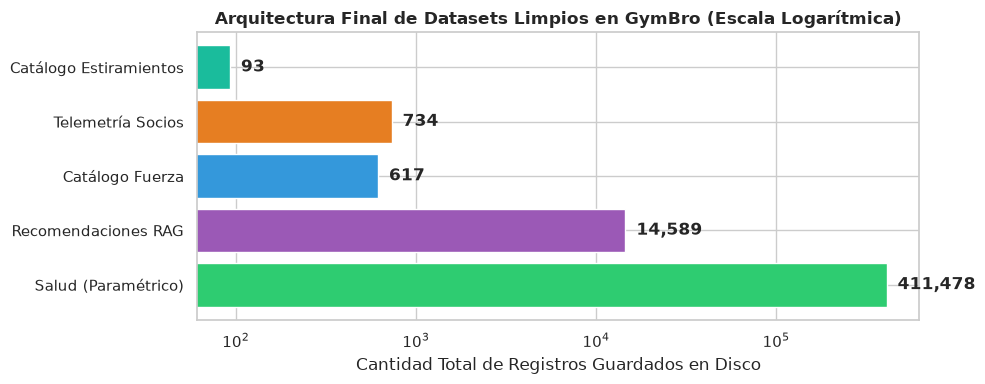

✅ PIPELINE ETL EJECUTADO CORRECTAMENTE EN 'gymbro_datasets'
1. Stretch Exercises:        93 filas
2. Gym Exercises:            617 filas
3. Gym Recommendation:       14,589 filas
4. Gym Members Tracking:     734 filas
5. Health Fitness Dataset:   411,478 filas


In [16]:
# ==============================================================================
# ETL INTEGRAL DE LOS 5 DATASETS - RUTA ABOGADA: gymbro_datasets
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración del estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print(" INICIANDO ETL INTEGRAL SOBRE LOS 5 ARCHIVOS EN 'gymbro_datasets'...")

# 1. DEFINICIÓN DE RUTAS CON PATHLIB (Evita errores de barras en Windows)
BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")

file_members = BASE_DIR / "gym_members_exercise_tracking.csv"
file_health = BASE_DIR / "health_fitness_dataset.csv"
file_gym_ex = BASE_DIR / "gym_exercise_dataset.csv"
file_stretch = BASE_DIR / "stretch_exercise_dataset.csv"
file_rec = BASE_DIR / "gym recommendation.xlsx"
file_rec_clean = BASE_DIR / "gym_recommendation_clean.xlsx"

# ------------------------------------------------------------------------------
# A. ETL: STRETCH EXERCISE DATASET (94 -> 93 Filas)
# ------------------------------------------------------------------------------
df_stretch = pd.read_csv(file_stretch)
df_stretch.dropna(subset=['Exercise Name'], inplace=True)
df_stretch['Exercise Name'] = df_stretch['Exercise Name'].astype(str).str.strip().str.replace('\u200b', '', regex=True)
df_stretch['Preparation'] = df_stretch['Preparation'].fillna("Posición inicial estándar de estiramiento.")
df_stretch['Execution'] = df_stretch['Execution'].fillna("Mantener la elongación durante 20-30 segundos.")
df_stretch['Synergist_Muscles'] = df_stretch['Synergist_Muscles'].fillna("Ninguno")

# ------------------------------------------------------------------------------
# B. ETL: GYM EXERCISE DATASET (617 Filas)
# ------------------------------------------------------------------------------
df_gym_ex = pd.read_csv(file_gym_ex)
df_gym_ex['Exercise Name'] = df_gym_ex['Exercise Name'].astype(str).str.strip().str.replace('\u200b', '', regex=True)
cols_anatomicas = ['Synergist_Muscles', 'Stabilizer_Muscles', 'Antagonist_Muscles', 'Dynamic_Stabilizer_Muscles', 'Secondary Muscles']
for col in cols_anatomicas:
    if col in df_gym_ex.columns:
        df_gym_ex[col] = df_gym_ex[col].fillna("Ninguno")

# ------------------------------------------------------------------------------
# C. ETL: GYM RECOMMENDATION MATRIX (14,589 Filas)
# ------------------------------------------------------------------------------
df_rec = pd.read_excel(file_rec)
df_rec.rename(columns={'Sex': 'Gender', 'Height': 'Height_cm', 'Weight': 'Weight_kg'}, inplace=True)

if df_rec['Height_cm'].max() < 3.0:
    df_rec['Height_cm'] = (df_rec['Height_cm'] * 100).round(1)

mapeo_genero = {'M': 'Male', 'F': 'Female', 'Male': 'Male', 'Female': 'Female'}
df_rec['Gender'] = df_rec['Gender'].astype(str).str.strip().map(mapeo_genero).fillna(df_rec['Gender'])

# ------------------------------------------------------------------------------
# D. ETL: HEALTH FITNESS DATASET (411,478 Filas - Sin Yoga/Basketball/Dancing/Tennis)
# ------------------------------------------------------------------------------
df_health = pd.read_csv(file_health)

descartar_health = ['basketball', 'dancing', 'tennis', 'yoga']
mask_health = ~df_health['activity_type'].astype(str).str.strip().str.lower().isin(descartar_health) if 'activity_type' in df_health.columns else ~df_health['Activity_Type'].astype(str).str.strip().str.lower().isin(descartar_health)
df_health_clean = df_health[mask_health].copy()

rename_health = {
    'age': 'Age', 'gender': 'Gender', 'height_cm': 'Height_cm', 'weight_kg': 'Weight_kg',
    'bmi': 'BMI', 'activity_type': 'Activity_Type', 'duration_minutes': 'Duration_Minutes',
    'calories_burned': 'Calories_Burned', 'blood_pressure_systolic': 'BP_Systolic',
    'blood_pressure_diastolic': 'BP_Diastolic', 'avg_heart_rate': 'Avg_BPM', 'resting_heart_rate': 'Resting_BPM'
}
df_health_clean.rename(columns=rename_health, inplace=True)

if 'health_condition' in df_health_clean.columns:
    df_health_clean['health_condition'] = df_health_clean['health_condition'].fillna("Sin Patología Declarada")

# ------------------------------------------------------------------------------
# E. ETL: GYM MEMBERS EXERCISE TRACKING (734 Filas - Sin Yoga)
# ------------------------------------------------------------------------------
df_members = pd.read_csv(file_members)

col_workout = 'Workout_Type' if 'Workout_Type' in df_members.columns else 'workout_type'
df_members_clean = df_members[df_members[col_workout].astype(str).str.strip().str.lower() != 'yoga'].copy()

if 'Session_Duration (hours)' in df_members_clean.columns:
    df_members_clean['Duration_Minutes'] = (df_members_clean['Session_Duration (hours)'] * 60).round(0).astype(int)
    df_members_clean.drop(columns=['Session_Duration (hours)'], inplace=True)

if 'Height (m)' in df_members_clean.columns:
    df_members_clean['Height_cm'] = (df_members_clean['Height (m)'] * 100).round(1)
    df_members_clean.drop(columns=['Height (m)'], inplace=True)

rename_members = {
    'Weight (kg)': 'Weight_kg', 'Water_Intake (liters)': 'Water_Intake_Liters',
    'Workout_Frequency (days/week)': 'Workout_Frequency_Days', 'Calories_Burned': 'Calories_Burned'
}
df_members_clean.rename(columns=rename_members, inplace=True)

# ------------------------------------------------------------------------------
# 2. GUARDAR Y SOBREESCRIBIR ARCHIVOS EN DISCO
# ------------------------------------------------------------------------------
df_stretch.to_csv(file_stretch, index=False)
df_gym_ex.to_csv(file_gym_ex, index=False)
df_health_clean.to_csv(file_health, index=False)
df_members_clean.to_csv(file_members, index=False)
df_rec.to_excel(file_rec_clean, index=False)

# ------------------------------------------------------------------------------
# 3. GENERACIÓN DE GRÁFICO RESUMEN DE LA ARQUITECTURA
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
datasets_nombres = ['Salud (Paramétrico)', 'Recomendaciones RAG', 'Catálogo Fuerza', 'Telemetría Socios', 'Catálogo Estiramientos']
cantidades = [len(df_health_clean), len(df_rec), len(df_gym_ex), len(df_members_clean), len(df_stretch)]
colores = ['#2ecc71', '#9b59b6', '#3498db', '#e67e22', '#1abc9c']

bars = plt.barh(datasets_nombres, cantidades, color=colores)
plt.xscale('log')
plt.title('Arquitectura Final de Datasets Limpios en GymBro (Escala Logarítmica)', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad Total de Registros Guardados en Disco')

for bar in bars:
    xval = bar.get_width()
    plt.text(xval * 1.15, bar.get_y() + bar.get_height()/2, f'{xval:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'arquitectura_final_datasets.png', dpi=300)
plt.show()

print("=" * 80)
print("PIPELINE ETL EJECUTADO CORRECTAMENTE EN 'gymbro_datasets'")
print("=" * 80)
print(f"1. Stretch Exercises:        {len(df_stretch):,} filas")
print(f"2. Gym Exercises:            {len(df_gym_ex):,} filas")
print(f"3. Gym Recommendation:       {len(df_rec):,} filas")
print(f"4. Gym Members Tracking:     {len(df_members_clean):,} filas")
print(f"5. Health Fitness Dataset:   {len(df_health_clean):,} filas")
print("=" * 80)

# Pautas para el Pipeline ETL Final

El objetivo de esta etapa es preparar los datasets antes de incorporarlos al ecosistema de **GymBro**. Las transformaciones buscan corregir valores faltantes, unificar unidades y categorías, eliminar inconsistencias de texto y dejar los datos en condiciones de ser utilizados tanto por la aplicación como por los procesos posteriores de análisis, generación de embeddings y RAG.

---

## 1. `stretch_exercise_dataset.csv`

**Catálogo de movilidad y estiramiento**

Este dataset contiene información descriptiva de ejercicios de movilidad y estiramiento. Antes de incorporarlo al catálogo de GymBro es necesario resolver registros incompletos y normalizar algunos campos de texto.

### 1.1. Eliminación de registros completamente vacíos

Se detectó la existencia de una fila sin información en ninguna de sus columnas.

**Transformación:**

Eliminar cualquier registro en el que todos los campos sean `NaN`.

```python
df_stretch.dropna(how="all", inplace=True)
```

El uso de `how="all"` es importante: no se eliminan registros que tengan solamente algunos campos faltantes, sino únicamente aquellos que no contienen ningún dato.

---

### 1.2. Campos de instrucciones incompletos

Los campos `Preparation` y `Execution` contienen valores faltantes.

Estos campos forman parte de la información que posteriormente puede utilizarse para explicar al usuario cómo realizar un ejercicio, por lo que no resulta conveniente conservarlos como `NaN`.

**Transformación:**

Reemplazar los valores faltantes por:

```text
Instrucción estándar de estiramiento asistido/estático
```

La misma descripción se utilizará en ambos campos cuando no exista información original.

```python
instruccion_default = "Instrucción estándar de estiramiento asistido/estático"

df_stretch["Preparation"] = (
    df_stretch["Preparation"]
    .fillna(instruccion_default)
)

df_stretch["Execution"] = (
    df_stretch["Execution"]
    .fillna(instruccion_default)
)
```

De esta manera, los registros mantienen una estructura uniforme y se evita transportar valores nulos innecesarios hacia las etapas posteriores del pipeline.

---

### 1.3. Músculos sinergistas

El campo `Synergist_Muscles` puede contener valores faltantes.

En este caso, la ausencia de información no significa necesariamente que el registro esté incompleto. Puede interpretarse como que no se especificaron músculos sinergistas principales para el ejercicio.

**Transformación:**

```text
Sin músculos sinergistas principales
```

```python
df_stretch["Synergist_Muscles"] = (
    df_stretch["Synergist_Muscles"]
    .fillna("Sin músculos sinergistas principales")
)
```

Esto permite mantener el campo como texto en todos los registros y facilita su utilización posterior en búsquedas, embeddings y generación de contexto.

---

## 2. `gym_exercise_dataset.csv`

**Catálogo de ejercicios de musculación**

Este dataset constituye el catálogo principal de ejercicios que utilizará GymBro para construir rutinas y proporcionar información sobre los ejercicios disponibles.

Las transformaciones se concentran principalmente en los campos anatómicos y en la limpieza de los nombres de los ejercicios.

### 2.1. Campos anatómicos con valores faltantes

Se identificaron valores `NaN` en los siguientes campos:

* `Stabilizer_Muscles`
* `Antagonist_Muscles`
* `Dynamic_Stabilizer_Muscles`

Estos campos son de naturaleza descriptiva. Cuando no existe información para alguno de ellos, se utilizará un valor explícito en lugar de conservar `NaN`.

**Transformación:**

```text
Ninguno
```

```python
columnas_musculares = [
    "Stabilizer_Muscles",
    "Antagonist_Muscles",
    "Dynamic_Stabilizer_Muscles"
]

df_gym[columnas_musculares] = (
    df_gym[columnas_musculares]
    .fillna("Ninguno")
)
```

Esto resulta especialmente útil en la etapa de serialización de los registros a JSON, donde se busca mantener una estructura predecible antes de generar embeddings y utilizar los datos en el sistema RAG.

---

### 2.2. Limpieza de caracteres invisibles

Se detectaron caracteres invisibles en algunos nombres de ejercicios, principalmente el carácter Unicode:

```text
\u200b
```

Este carácter corresponde a un **Zero Width Space** (espacio de ancho cero).

Aunque visualmente no puede distinguirse, forma parte del contenido de la cadena y puede generar diferencias entre valores que aparentemente son iguales.

Por ejemplo:

```text
"Barbell Bench Press"
"Barbell​ Bench Press"
```

Visualmente pueden parecer idénticos, pero para Python son cadenas diferentes.

Esto puede provocar:

* Duplicados aparentes.
* Problemas al comparar nombres.
* Dificultades al realizar búsquedas.
* Registros duplicados durante procesos de agrupación.
* Diferencias innecesarias al generar embeddings.

**Transformación:**

Eliminar los caracteres invisibles y normalizar los espacios de los nombres.

```python
df_gym["Exercise"] = (
    df_gym["Exercise"]
    .str.replace("\u200b", "", regex=False)
    .str.strip()
)
```

Si durante la exploración se detectan otros caracteres Unicode invisibles, deberán incorporarse a la misma etapa de normalización.

---

## 3. `gym recommendation.xlsx`

**Matriz de referencia para recomendaciones y RAG**

Este archivo contiene información utilizada como referencia para establecer recomendaciones relacionadas con las características físicas, el nivel y los objetivos del usuario.

La principal tarea consiste en adaptar su estructura al modelo de datos definido para GymBro.

### 3.1. Conversión de altura

La columna `Height` está expresada en metros.

Por ejemplo:

```text
1.68
```

En el resto del ecosistema de GymBro la altura se maneja en centímetros, por lo que es necesario realizar la conversión durante el proceso ETL.

**Transformación:**

$$
HeightCm = Height \times 100
$$

Ejemplos:

| `Height` (m) | `HeightCm` (cm) |
| -----------: | --------------: |
|         1.68 |             168 |
|         1.75 |             175 |
|         1.82 |             182 |

En Python:

```python
df_recommendation["Height"] = (
    df_recommendation["Height"] * 100
)
```

Si se decide conservar el nombre original de la columna, su unidad deberá quedar documentada. Como alternativa, resulta más claro renombrarla a `HeightCm`.

```python
df_recommendation.rename(
    columns={"Height": "HeightCm"},
    inplace=True
)
```

---

### 3.2. Homologación del género

La columna original se denomina:

```text
Sex
```

Para mantener una nomenclatura consistente con el modelo de datos se utilizará:

```text
Gender
```

**Transformación:**

```python
df_recommendation.rename(
    columns={"Sex": "Gender"},
    inplace=True
)
```

Los valores deberán normalizarse a las categorías definidas:

* `Male`
* `Female`

Antes de realizar el mapeo es conveniente normalizar el texto para evitar diferencias producidas por mayúsculas, minúsculas o espacios.

```python
df_recommendation["Gender"] = (
    df_recommendation["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)
```

---

### 3.3. Homologación de `Level`

Los valores originales de `Level` son:

| Valor original | Valor homologado |
| -------------- | ---------------- |
| `Underweight`  | Bajo peso        |
| `Normal`       | Normal           |
| `Overweight`   | Sobrepeso        |

El mapeo puede realizarse mediante un diccionario:

```python
level_map = {
    "Underweight": "Bajo peso",
    "Normal": "Normal",
    "Overweight": "Sobrepeso"
}

df_recommendation["Level"] = (
    df_recommendation["Level"]
    .map(level_map)
)
```

---

### 3.4. Homologación de `Fitness Goal`

Los objetivos originales del dataset son:

| Valor original | Valor homologado  |
| -------------- | ----------------- |
| `Weight Gain`  | Aumento de peso   |
| `Weight Loss`  | Pérdida de peso   |
| `Muscle Gain`  | Ganancia muscular |

La transformación puede realizarse de la siguiente manera:

```python
fitness_goal_map = {
    "Weight Gain": "Aumento de peso",
    "Weight Loss": "Pérdida de peso",
    "Muscle Gain": "Ganancia muscular"
}

df_recommendation["Fitness Goal"] = (
    df_recommendation["Fitness Goal"]
    .map(fitness_goal_map)
)
```

La finalidad de estas transformaciones no es solamente traducir los valores, sino establecer una única nomenclatura para las categorías que posteriormente utilizarán la aplicación, los modelos de análisis y el sistema RAG.

---

## 4. `health_fitness_dataset.csv`

**Base fisiológica de referencia**

Este dataset contiene información relacionada con variables fisiológicas, actividad física y condiciones de salud.

### 4.1. Tratamiento de `health_condition`

La columna `health_condition` presenta aproximadamente **293.094 valores `NaN`**.

En lugar de mantener estos valores como nulos, se utilizará una categoría explícita:

```text
Saludable / Sin patología
```

**Transformación:**

```python
df_health["health_condition"] = (
    df_health["health_condition"]
    .fillna("Saludable / Sin patología")
)
```

Esta transformación debe interpretarse con cuidado: el valor asignado representa la **ausencia de una condición registrada en el dataset**, no un diagnóstico médico.

Por lo tanto, dentro del modelo de datos esta categoría debe entenderse como:

> No se informó una patología o condición de salud en el registro.

---

# 5. Resumen de transformaciones

| Dataset                        | Transformaciones                                                                                             |
| ------------------------------ | ------------------------------------------------------------------------------------------------------------ |
| `stretch_exercise_dataset.csv` | Eliminar filas completamente vacías, completar `Preparation`, `Execution` y `Synergist_Muscles`.             |
| `gym_exercise_dataset.csv`     | Completar campos anatómicos y eliminar caracteres Unicode invisibles de los nombres.                         |
| `gym recommendation.xlsx`      | Convertir `Height` de metros a centímetros, renombrar `Sex` a `Gender` y homologar `Level` y `Fitness Goal`. |
| `health_fitness_dataset.csv`   | Completar los valores faltantes de `health_condition`.                                                       |

---

# 6. Secuencia de procesamiento

Las transformaciones se aplicarán siguiendo un orden que permita reducir progresivamente las inconsistencias de los datos:

```text
Datos originales
      │
      ▼
Carga de datasets
      │
      ▼
Inspección de estructura y tipos
      │
      ▼
Eliminación de registros completamente vacíos
      │
      ▼
Tratamiento de valores faltantes
      │
      ▼
Normalización de texto
      │
      ▼
Homologación de unidades
      │
      ▼
Homologación de categorías
      │
      ▼
Validación de datos transformados
      │
      ▼
Datasets preparados
      │
      ├──► Análisis exploratorio
      │
      ├──► PostgreSQL / EF Core
      │
      └──► Embeddings / RAG / Ollama
```

El resultado de esta etapa será un conjunto de datasets con estructuras consistentes y preparados para las siguientes fases del proyecto: **análisis exploratorio, almacenamiento relacional, generación de embeddings y construcción del sistema de recomendaciones mediante RAG y Ollama**.


In [17]:
# ==============================================================================
# DELIMITACIÓN DE ÁMBITO: SALA DE MUSCULACIÓN Y COMPLEMENTOS
# ==============================================================================
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")

file_health = BASE_DIR / "health_fitness_dataset.csv"
file_gym_ex = BASE_DIR / "gym_exercise_dataset.csv"
file_stretch = BASE_DIR / "stretch_exercise_dataset.csv"

# 1. Cargar archivos
df_health = pd.read_csv(file_health)
df_gym_ex = pd.read_csv(file_gym_ex)
df_stretch = pd.read_csv(file_stretch)

# 2. DEPURACIÓN EN HEALTH_FITNESS: Eliminar Natación
filas_health_antes = len(df_health)
df_health = df_health[df_health['Activity_Type'] != 'Natación'].copy()

# 3. DEPURACIÓN EN CATÁLOGOS: Eliminar grupo muscular 'Neck'
filas_gym_antes = len(df_gym_ex)
filas_stretch_antes = len(df_stretch)

df_gym_ex = df_gym_ex[df_gym_ex['Main_muscle'] != 'Neck'].copy()
df_stretch = df_stretch[df_stretch['Main_muscle'] != 'Neck'].copy()

# 4. Sobreescribir los CSVs limpios
df_health.to_csv(file_health, index=False)
df_gym_ex.to_csv(file_gym_ex, index=False)
df_stretch.to_csv(file_stretch, index=False)

print("=" * 80)
print(" DELIMITACIÓN DE ÁMBITO DE GIMNASIO APLICADA EXITOSAMENTE")
print("=" * 80)
print(f"• health_fitness_dataset.csv: {filas_health_antes:,} -> {len(df_health):,} filas (Natación eliminada)")
print(f"• gym_exercise_dataset.csv:   {filas_gym_antes} -> {len(df_gym_ex)} filas (Ejercicios de Cuello eliminados)")
print(f"• stretch_exercise_dataset.csv: {filas_stretch_antes} -> {len(df_stretch)} filas (Estiramientos de Cuello eliminados)")
print("=" * 80)

✅ DELIMITACIÓN DE ÁMBITO DE GIMNASIO APLICADA EXITOSAMENTE
• health_fitness_dataset.csv: 411,478 -> 343,446 filas (Natación eliminada)
• gym_exercise_dataset.csv:   617 -> 597 filas (Ejercicios de Cuello eliminados)
• stretch_exercise_dataset.csv: 93 -> 91 filas (Estiramientos de Cuello eliminados)


# Delimitación del ámbito y depuración de datasets

Delimitar el ámbito de la aplicación permite reducir datos que introducen ruido y concentrar el análisis en actividades propias de un **gimnasio de musculación y complementos**: pesas, poleas, máquinas y cardio de sala.

## 1. Elementos no relevantes y pautas de depuración

### A. `health_fitness_dataset.csv`

**Candidato a eliminar:** `Natación` — **68.032 registros**.

**Justificación:**
Aunque la natación es una actividad aeróbica, no se realiza dentro de la sala de musculación ni utiliza el equipamiento contemplado en la aplicación, como cintas, bicicletas, elípticas, máquinas o pesas.

**Acción:**
Filtrar y eliminar todos los registros correspondientes a `Natación`.

La base paramétrica quedaría:

$$
411.478 - 68.032 = 343.446
$$

**Resultado:** `343.446` registros correspondientes exclusivamente a actividades de cardio y fuerza de sala:

* Cinta
* Bicicleta
* Caminadora
* HIIT
* Fuerza

---

### B. `gym_exercise_dataset.csv`

**Dataset:** 617 ejercicios.

**Candidato a depurar/revisar:** ejercicios específicos del grupo muscular `Neck` (cuello) — **20 ejercicios**.

**Justificación:**
Los ejercicios específicos de cuello mediante arnés, cable o máquinas de flexión cervical están orientados principalmente a disciplinas deportivas de contacto, como boxeo, MMA o rugby.

Además, no son ejercicios habituales dentro de rutinas generales de musculación y presentan un mayor riesgo si son recomendados sin supervisión específica.

**Acción:**
Eliminar de la tabla de ejercicios los registros cuyo grupo muscular principal corresponda a `Neck`.

Esto evita que el sistema de recomendaciones pueda sugerir ejercicios de flexión o extensión cervical con arnés dentro de rutinas generales de hipertrofia, acondicionamiento físico o salud.

---

### C. `stretch_exercise_dataset.csv`

**Dataset:** 93 ejercicios.

**Candidato a depurar:** estiramientos correspondientes al grupo muscular `Neck` — **2 ejercicios**.

**Acción:**
Aplicar el mismo criterio utilizado en el catálogo de musculación y eliminar los ejercicios correspondientes al grupo `Neck`.

De esta manera, ambos catálogos mantienen el mismo alcance y se evita que el sistema recomiende ejercicios o estiramientos específicos de cuello que quedan fuera del objetivo principal de la aplicación.

---

## 2. Resultado esperado de la depuración

| Dataset                        | Registros / ejercicios originales | Elementos eliminados |   Resultado |
| ------------------------------ | --------------------------------: | -------------------: | ----------: |
| `health_fitness_dataset.csv`   |                           411.478 |    68.032 `Natación` | **343.446** |
| `gym_exercise_dataset.csv`     |                               617 |            20 `Neck` |     **597** |
| `stretch_exercise_dataset.csv` |                                93 |             2 `Neck` |      **91** |

El criterio general será mantener únicamente información relacionada con el entrenamiento y las actividades que forman parte del ámbito definido para **GymBro**.


# Clasificación y normalización de categorías de IMC

El campo correspondiente al **Índice de Masa Corporal (IMC / BMI)** utiliza cuatro categorías. Para GymBro conviene dejar estas categorías definidas desde el ETL, en lugar de corregirlas más adelante en C#, PostgreSQL o en la capa de recomendaciones.

| Categoría   |      Rango de IMC |
| ----------- | ----------------: |
| Bajo Peso   |      `IMC < 18.5` |
| Peso Normal | `18.5 ≤ IMC < 25` |
| Sobrepeso   |   `25 ≤ IMC < 30` |
| Obesidad    |        `IMC ≥ 30` |

Estas categorías corresponden a la clasificación utilizada habitualmente para adultos. El valor del IMC se obtiene mediante:

$$
IMC = \frac{Peso;(kg)}{Altura;(m)^2}
$$

---

## Corrección detectada en los datos

Durante la revisión del dataset aparece la categoría:

```text
Obuse
```

Se trata de un error de escritura de `Obese`.

Hay **3.439 registros** afectados por este problema. No es conveniente conservar `Obuse` como una categoría válida, ya que terminaría propagándose hacia el modelo de datos y obligaría a contemplar una categoría incorrecta en las consultas, enums y reglas de negocio.

La corrección debe hacerse durante el ETL.

---

## Criterio adoptado para GymBro

Para el dominio de GymBro se utilizará la nomenclatura en **español**, ya que estas categorías forman parte del modelo de negocio de la aplicación y posteriormente podrán ser mostradas directamente al usuario.

El mapeo definitivo será:

| Valor encontrado | Valor normalizado |
| ---------------- | ----------------- |
| `Underweight`    | `Bajo Peso`       |
| `Normal`         | `Peso Normal`     |
| `Overweight`     | `Sobrepeso`       |
| `Obuse`          | `Obesidad`        |
| `Obese`          | `Obesidad`        |

Se contempla tanto `Obuse` como `Obese` en la transformación. De esta forma, el ETL corrige el error existente y, al mismo tiempo, evita que una variante correcta en inglés termine generando una categoría diferente dentro de la base.

---

## Transformación en Python

El reemplazo puede realizarse directamente sobre la columna correspondiente:

```python
bmi_map = {
    "Underweight": "Bajo Peso",
    "Normal": "Peso Normal",
    "Overweight": "Sobrepeso",
    "Obuse": "Obesidad",
    "Obese": "Obesidad"
}

df["BMI_Category"] = (
    df["BMI_Category"]
    .str.strip()
    .map(bmi_map)
)
```

Antes de aplicar el mapeo es conveniente revisar los valores existentes:

```python
df["BMI_Category"].value_counts(dropna=False)
```

Después de la transformación:

```python
df["BMI_Category"].value_counts(dropna=False)
```

El segundo resultado debería mostrar únicamente las categorías definidas para GymBro, además de posibles valores nulos que deberán analizarse por separado.

---

## Representación en C#

La nomenclatura utilizada en el dataset puede reflejarse en un `enum` del dominio:

```csharp
public enum CategoriaIMCEnum
{
    BajoPeso,
    PesoNormal,
    Sobrepeso,
    Obesidad
}
```

De esta manera, la aplicación no depende de cadenas como `"Obuse"`, `"Obese"` o `"Overweight"` para determinar el estado nutricional.

Si además se desea conservar el valor numérico del IMC, la categoría debería considerarse un dato derivado:

```text
Peso + Altura
      │
      ▼
     IMC
      │
      ▼
CategoriaIMCEnum
```

Esto permite que la categoría pueda recalcularse si posteriormente se modifica el peso o la altura del socio.

---

## Consideración para PostgreSQL

En PostgreSQL debería almacenarse únicamente la categoría normalizada. No tiene sentido conservar `Obuse` como un valor histórico si el objetivo del campo es representar una categoría válida del dominio.

El resultado esperado es:

```text
Bajo Peso
Peso Normal
Sobrepeso
Obesidad
```

Con esto, las consultas y filtros posteriores pueden trabajar sobre un conjunto cerrado de valores y se evita que un simple error de tipeo termine convirtiéndose en una regla especial dentro del código de la aplicación.

---

## Regla utilizada durante el ETL

La normalización del campo puede resumirse así:

$$
BMI < 18.5 \rightarrow Bajo\ Peso
$$

$$
18.5 \le BMI < 25 \rightarrow Peso\ Normal
$$

$$
25 \le BMI < 30 \rightarrow Sobrepeso
$$

$$
BMI \ge 30 \rightarrow Obesidad
$$

El valor textual existente en el dataset no debería ser la fuente de verdad cuando también se dispone del valor numérico de IMC. En una etapa posterior del ETL conviene **validar que la categoría declarada coincida con la categoría calculada a partir del IMC**, ya que esto permite detectar errores adicionales que un simple reemplazo de textos no encontraría.


In [18]:
# ==============================================================================
# LIMPIEZA DE ACTIVIDADES Y EQUIPAMIENTO EN GYM RECOMMENDATION
# ==============================================================================
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_rec = BASE_DIR / "gym_recommendation.xlsx"

if not file_rec.exists():
    file_rec = Path("gym recommendation.xlsx")

df_rec = pd.read_excel(file_rec)

# 1. MAPEO DE SUSTITUCIÓN PARA LA COLUMNA EXERCISES
mapeo_ejercicios = {
    'Brisk walking, cycling, swimming, running , or dancing.': 'Cinta / Treadmill, Bicicleta Fija / Spinning, Escaladora, Elíptica.',
    'brisk walking, cycling, swimming, or dancing.': 'Cinta / Treadmill, Bicicleta Fija / Spinning, Escaladora.',
    'Walking, Yoga, Swimming.': 'Cinta / Treadmill, Caminadora, Bicicleta Fija.',
    'Squats, yoga, deadlifts, bench presses, and overhead presses': 'Sentadillas, Peso Muerto, Press de Banca, Press Militar y Ejercicios Auxiliares.',
    'Squats, deadlifts, bench presses, and overhead presses': 'Sentadillas, Peso Muerto, Press de Banca y Press Militar.'
}

# 2. MAPEO DE SUSTITUCIÓN PARA LA COLUMNA EQUIPMENT
def limpiar_equipamiento(texto):
    texto_str = str(texto)
    # Reemplazar mat de yoga o zapatos por equipamiento de sala
    texto_str = texto_str.replace('Yoga Mat', 'Esterilla de Entrenamiento / Banco')
    texto_str = texto_str.replace('Light athletic shoes, resistance bands, and light dumbbells.', 'Mancuernas Livianas, Bandas de Resistencia y Bancos.')
    return texto_str

# 3. APLICAR TRANSFORMACIONES
df_rec['Exercises'] = df_rec['Exercises'].str.strip().map(mapeo_ejercicios).fillna(df_rec['Exercises'])
df_rec['Equipment'] = df_rec['Equipment'].apply(limpiar_equipamiento)

# 4. SOBREESCRIBIR ARCHIVO LIMPIO
output_file = BASE_DIR / "gym_recommendation.xlsx" if BASE_DIR.exists() else Path("gym_recommendation.xlsx")
df_rec.to_excel(output_file, index=False)

print("=" * 80)
print(" LIMPIEZA DE ACTIVIDADES NO-GYM COMPLETADA EN RECOMMENDATION MATRIX")
print("=" * 80)
print(" Distribución final de 'Exercises':")
print(df_rec['Exercises'].value_counts())
print("=" * 80)

✅ LIMPIEZA DE ACTIVIDADES NO-GYM COMPLETADA EN RECOMMENDATION MATRIX
📊 Distribución final de 'Exercises':
Exercises
Cinta / Treadmill, Bicicleta Fija / Spinning, Escaladora, Elíptica.                 4206
Sentadillas, Peso Muerto, Press de Banca y Press Militar.                           3632
Sentadillas, Peso Muerto, Press de Banca, Press Militar y Ejercicios Auxiliares.    3376
Cinta / Treadmill, Caminadora, Bicicleta Fija.                                      1688
Cinta / Treadmill, Bicicleta Fija / Spinning, Escaladora.                           1687
Name: count, dtype: int64


In [19]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_rec = BASE_DIR / "gym_recommendation.xlsx"

if not file_rec.exists():
    file_rec = Path("gym recommendation.xlsx")

df_rec = pd.read_excel(file_rec)

# Diccionario de corrección para el campo Level
mapeo_level = {
    'Obuse': 'Obese',          # Corregir error tipográfico (Obuse -> Obese)
    'Underweight': 'Underweight',
    'Normal': 'Normal',
    'Overweight': 'Overweight'
}

# Aplicar la corrección
df_rec['Level'] = df_rec['Level'].str.strip().map(mapeo_level).fillna(df_rec['Level'])

# Guardar cambios
output_file = BASE_DIR / "gym_recommendation.xlsx" if BASE_DIR.exists() else Path("gym_recommendation.xlsx")
df_rec.to_excel(output_file, index=False)

print("=" * 70)
print(" CORRECCIÓN DEL CAMPO 'Level' COMPLETADA")
print("=" * 70)
print(" Conteo corregido en 'Level':")
print(df_rec['Level'].value_counts())
print("=" * 70)

✅ CORRECCIÓN DEL CAMPO 'Level' COMPLETADA
📊 Conteo corregido en 'Level':
Level
Overweight     4142
Normal         3650
Obese          3439
Underweight    3358
Name: count, dtype: int64


# Arquitectura de Vinculación y Agrupación

La relación entre la matriz de recomendaciones y el catálogo de ejercicios no debería resolverse almacenando nombres de ejercicios directamente dentro de `gym_recommendation`.

Si una recomendación contiene algo como `"Bench Press, Lat Pulldown, Squat..."`, el sistema queda atado a esos ejercicios concretos. Cualquier modificación del catálogo obligaría a modificar también las recomendaciones.

La alternativa es utilizar `gym_recommendation` para describir **qué tipo de entrenamiento corresponde al perfil del socio** y dejar que la selección concreta de ejercicios se realice sobre el catálogo.

La separación quedaría de la siguiente manera:

```text
[MatrizRecomendacion]
    │
    ├── Perfil del socio
    │     ├── IMC
    │     ├── Hipertensión
    │     ├── Diabetes
    │     └── Objetivo
    │
    ├── Información nutricional
    ├── Recomendaciones generales
    └── Routine_Category
              │
              ▼
       [Regla de Prescripción]
              │
              ├── TipoFitness
              ├── Difficulty máxima
              └── Grupos musculares
                       │
                       ▼
             [CatalogoEjercicios]
              gym_exercise_dataset
                       │
                       ▼
              Filtro dinámico
           SQL / LINQ / Python
                       │
                       ▼
              Ejercicios válidos
```

La ventaja principal de este esquema es que la recomendación deja de depender de ejercicios específicos. El catálogo puede crecer, reducirse o modificarse sin tener que reconstruir la matriz de recomendaciones.

---

## 1. Reclasificación de `gym_recommendation`

El campo `Exercises`, tal como aparece originalmente en el dataset, contiene una descripción demasiado genérica para utilizarlo como relación con el catálogo.

En lugar de conservarlo como fuente de ejercicios concretos, se propone transformarlo en una categoría que represente el tipo de rutina que debe construirse.

### Categorías de rutina

| `Fitness Goal`       | Tipo de entrenamiento   | `Routine_Category`   | Regla de selección                                                                            |
| -------------------- | ----------------------- | -------------------- | --------------------------------------------------------------------------------------------- |
| `Weight Loss`        | Cardio Fitness          | `CARDIO_AEROBICO`    | `Equipment` ∈ `Treadmill`, `Bike`, `Elliptical` y `Difficulty` ≤ 3                            |
| `Weight Gain`        | Muscular Fitness        | `FUERZA_HIPERTROFIA` | `Mechanics = Compound` y grupos musculares principales `Chest`, `Back`, `Thighs`, `Shoulder`  |
| Población con riesgo | Hipertensión / Diabetes | `SALUD_PRECAUCION`   | `Difficulty` ≤ 2 y exclusión de ejercicios que puedan implicar maniobras de Valsalva intensas |

El campo `Exercises` original deja de representar una lista de ejercicios y pasa a ser información derivada de la categoría de rutina.

Por ejemplo:

```text
Fitness Goal = Weight Loss
        │
        ▼
CARDIO_AEROBICO
        │
        ▼
buscar en CatalogoEjercicios
        │
        ├── Treadmill
        ├── Bike
        └── Elliptical
```

El resultado final dependerá de los ejercicios disponibles en el catálogo en ese momento.

---

## 2. Segmentación del catálogo por dificultad

Luego de la depuración del catálogo, `gym_exercise_dataset.csv` contiene **597 ejercicios**.

La columna `Difficulty` permite utilizar una primera clasificación funcional sin tener que crear manualmente una categoría para cada ejercicio.

| `Difficulty` | Nivel                     | Características generales                                                                                    |
| -----------: | ------------------------- | ------------------------------------------------------------------------------------------------------------ |
|        `1–2` | Principiante / Precaución | Ejercicios guiados, máquinas selectorizadas (`Lever`, `Selectorized`) y cardio continuo                      |
|          `3` | Intermedio                | Mancuernas (`Dumbbell`), poleas (`Cable`) y ejercicios con peso corporal                                     |
|        `4–5` | Avanzado                  | Mayor demanda técnica y ejercicios con peso libre pesado, especialmente `Barbell` y levantamientos olímpicos |

Esta clasificación no debería interpretarse como una regla absoluta sobre la dificultad fisiológica de un ejercicio. Sirve principalmente como **criterio inicial de filtrado del catálogo**.

Por ejemplo, un ejercicio con `Difficulty = 2` podría ser técnicamente sencillo pero no necesariamente adecuado para cualquier persona. La dificultad debe combinarse con el perfil del socio y con las demás restricciones de la prescripción.

---

## 3. Construcción dinámica de la rutina

Una vez determinado el perfil de prescripción, la aplicación puede consultar el catálogo utilizando varios criterios simultáneamente.

Conceptualmente:

```text
PerfilSocio
    │
    ├── Objetivo
    ├── IMC
    ├── Edad
    ├── Condiciones registradas
    └── Nivel de experiencia
            │
            ▼
    PerfilPrescripcion
            │
            ├── Routine_Category
            ├── DifficultyMax
            ├── Equipment permitido
            └── Grupos musculares
                    │
                    ▼
             CatalogoEjercicios
                    │
                    ▼
             Aplicar filtros
                    │
                    ▼
             Ejercicios candidatos
                    │
                    ▼
             Selección de rutina
```

Por ejemplo, para una persona cuyo perfil determine:

```text
Routine_Category = FUERZA_HIPERTROFIA
DifficultyMax    = 3
MusculosObjetivo = Chest, Back, Thighs
```

la consulta no debería buscar ejercicios específicos como `"Bench Press"` o `"Lat Pulldown"`.

Debería buscar ejercicios que cumplan las condiciones:

```text
Mechanics = Compound
AND Difficulty <= 3
AND MuscleGroup IN (Chest, Back, Thighs)
```

De esta manera, si mañana se agrega un nuevo ejercicio al catálogo que cumple esos criterios, automáticamente pasa a estar disponible para el sistema de recomendaciones.

---

## 4. Separación de responsabilidades

Con esta estructura cada conjunto de datos tiene una responsabilidad diferente:

| Componente             | Responsabilidad                                         |
| ---------------------- | ------------------------------------------------------- |
| `gym_recommendation`   | Determinar qué tipo de estrategia corresponde al perfil |
| `PerfilPrescripcion`   | Traducir esa estrategia en restricciones concretas      |
| `gym_exercise_dataset` | Proporcionar los ejercicios disponibles                 |
| Motor de selección     | Aplicar filtros y construir la rutina                   |
| Ollama / RAG           | Explicar y contextualizar la recomendación              |

Esto evita mezclar **reglas de negocio** con **datos del catálogo**.

La matriz no necesita saber qué ejercicios existen. El catálogo no necesita saber por qué un socio debe hacer una determinada rutina.

---

## 5. Estructura propuesta de `PerfilPrescripcion`

Como concepto de dominio, una prescripción podría representarse mediante:

```text
PerfilPrescripcion
│
├── Id
├── RoutineCategory
├── TipoFitness
├── DifficultyMax
├── GruposMuscularesObjetivo
├── EquipamientoPermitido
└── Restricciones
```

Por ejemplo:

```text
RoutineCategory: FUERZA_HIPERTROFIA
TipoFitness:     MuscularFitness
DifficultyMax:   3

GruposMuscularesObjetivo:
    - Chest
    - Back
    - Thighs
    - Shoulder

EquipamientoPermitido:
    - Dumbbell
    - Cable
    - Lever

Restricciones:
    - Difficulty <= 3
    - Mechanics = Compound
```

La estructura permite que posteriormente estas reglas puedan almacenarse en PostgreSQL y ser consultadas desde EF Core, en lugar de quedar codificadas directamente dentro del servicio de recomendaciones.

---

## 6. Resultado de la arquitectura

El flujo completo queda desacoplado en tres niveles:

```text
      PERFIL DEL SOCIO
             │
             ▼
     MATRIZ DE RECOMENDACIÓN
             │
             ▼
     PERFIL DE PRESCRIPCIÓN
             │
             ▼
       REGLAS DE FILTRADO
             │
             ▼
      CATÁLOGO DE EJERCICIOS
             │
             ▼
       EJERCICIOS CANDIDATOS
             │
             ▼
        RUTINA GENERADA
             │
             ▼
       RAG + OLLAMA
             │
             ▼
   Explicación personalizada
```

La idea central es mantener una distinción clara entre **decidir qué necesita el socio** y **decidir qué ejercicio concreto se le asigna**.

La primera parte pertenece a la matriz de recomendaciones y a las reglas de prescripción. La segunda se resuelve consultando dinámicamente el catálogo de ejercicios.


In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_rec = BASE_DIR / "gym_recommendation.xlsx" if (BASE_DIR / "gym_recommendation.xlsx").exists() else Path("gym recommendation.xlsx")
file_ex = BASE_DIR / "gym_exercise_dataset.csv" if (BASE_DIR / "gym_exercise_dataset.csv").exists() else Path("gym_exercise_dataset.csv")

df_rec = pd.read_excel(file_rec)
df_ex = pd.read_csv(file_ex)

# 1. CREAR CATEGORÍA DE RUTINA EN RECOMMENDATION MATRIX
def asignar_categoria_rutina(row):
    if row['Hypertension'] == 'Yes' or row['Diabetes'] == 'Yes':
        return 'RUTINA_ADAPTADA_SALUD'
    elif row['Fitness Goal'] == 'Weight Loss':
        return 'RUTINA_CARDIO_QUEMA_CALORICA'
    elif row['Fitness Goal'] == 'Weight Gain':
        return 'RUTINA_FUERZA_HIPERTROFIA'
    return 'RUTINA_GENERAL_AEROBICA'

df_rec['Routine_Category'] = df_rec.apply(asignar_categoria_rutina, axis=1)

# Eliminar el texto estático repetitivo de Exercises para dejar la matriz pura de Nutrición + Categoría
df_rec.drop(columns=['Exercises'], inplace=True, errors='ignore')

# 2. CREAR ETIQUETA DE NIVEL EN EL CATÁLOGO DE EJERCICIOS (597 registros)
def clasificar_nivel_ejercicio(diff):
    if diff <= 2:
        return 'Principiante'
    elif diff == 3:
        return 'Intermedio'
    else:
        return 'Avanzado'

df_ex['Difficulty_Level'] = df_ex['Difficulty (1-5)'].apply(clasificar_nivel_ejercicio)

# 3. SOBREESCRIBIR Y EXPORTAR ARCHIVOS REFACTORIZADOS
df_rec.to_excel(BASE_DIR / "gym_recommendation.xlsx" if BASE_DIR.exists() else "gym_recommendation.xlsx", index=False)
df_ex.to_csv(BASE_DIR / "gym_exercise_dataset.csv" if BASE_DIR.exists() else "gym_exercise_dataset.csv", index=False)

print("=" * 80)
print(" REFACTORIZACIÓN Y VINCULACIÓN COMPLETADA")
print("=" * 80)
print(" Matriz de Recomendación (Categorías de Rutina asociadas a Nutrición):")
print(df_rec['Routine_Category'].value_counts())

print("\n Catálogo de Ejercicios (Clasificación por Nivel de Dificultad):")
print(df_ex['Difficulty_Level'].value_counts())
print("=" * 80)

✅ REFACTORIZACIÓN Y VINCULACIÓN COMPLETADA
📊 Matriz de Recomendación (Categorías de Rutina asociadas a Nutrición):
Routine_Category
RUTINA_ADAPTADA_SALUD           10127
RUTINA_CARDIO_QUEMA_CALORICA     2518
RUTINA_FUERZA_HIPERTROFIA        1944
Name: count, dtype: int64

📊 Catálogo de Ejercicios (Clasificación por Nivel de Dificultad):
Difficulty_Level
Intermedio      250
Principiante    234
Avanzado        113
Name: count, dtype: int64


# Mapeo al Dominio de C# y Vinculación del Ecosistema GymBro

La columna `Workout_Type` de `gym_members_exercise_tracking.csv` contiene un conjunto reducido de categorías que resulta adecuado para representarlo como un `enum` dentro del dominio de GymBro.

La idea es que el dataset utilice los valores necesarios durante la etapa de análisis y que, una vez incorporados al sistema, estos valores queden representados mediante tipos propios del dominio.

## 1. Mapeo de `Workout_Type` a C#

Las categorías identificadas son:

* `Cardio`
* `Strength`
* `HIIT`

En el dominio de C# se pueden representar mediante:

```csharp
namespace GymBro.Domain.Enums
{
    public enum TipoEntrenamiento
    {
        Cardio = 1,
        Fuerza = 2,
        HIIT = 3
    }
}
```

El valor `Strength` del dataset se corresponde con `Fuerza` dentro del dominio.

De esta forma, la aplicación no necesita trabajar constantemente con comparaciones como:

```csharp
if (workoutType == "Strength")
```

sino con el tipo definido por el propio dominio:

```csharp
if (sesion.TipoEntrenamiento == TipoEntrenamiento.Fuerza)
{
    // ...
}
```

Además de ser más seguro frente a errores de escritura, esto permite que el compilador ayude a detectar valores inválidos.

---

## 2. Relación entre los datasets

A partir de esta clasificación se puede establecer una relación entre tres fuentes que cumplen funciones diferentes dentro del sistema.

```text
gym_members_exercise_tracking
        │
        │  Actividad realizada
        ▼
   TipoEntrenamiento
        │
        │
        ▼
gym_recommendation
        │
        │  Regla de prescripción
        ▼
Routine_Category
        │
        │
        ▼
gym_exercise_dataset
        │
        │  Selección de ejercicios
        ▼
   Rutina propuesta
```

Cada dataset aporta una parte distinta de la información:

| Dataset                             | Función                                                                |
| ----------------------------------- | ---------------------------------------------------------------------- |
| `gym_members_exercise_tracking.csv` | Registra el entrenamiento realizado por el socio                       |
| `gym_recommendation`                | Define la estrategia de entrenamiento según el perfil                  |
| `gym_exercise_dataset.csv`          | Contiene los ejercicios que pueden utilizarse para construir la rutina |

La vinculación no implica que los tres datasets tengan que compartir exactamente las mismas columnas. La relación se establece mediante categorías y reglas de negocio.

---

## 3. Correspondencia entre `Routine_Category` y `TipoEntrenamiento`

Las categorías definidas para las recomendaciones pueden traducirse al tipo de entrenamiento del dominio.

| `Routine_Category`             | `TipoEntrenamiento` | Criterio                                           |
| ------------------------------ | ------------------- | -------------------------------------------------- |
| `RUTINA_CARDIO_QUEMA_CALORICA` | `Cardio` / `HIIT`   | Trabajo cardiovascular orientado al gasto calórico |
| `RUTINA_FUERZA_HIPERTROFIA`    | `Fuerza`            | Trabajo muscular orientado a fuerza e hipertrofia  |
| `RUTINA_ADAPTADA_SALUD`        | `Cardio`            | Trabajo cardiovascular de menor intensidad         |

La última categoría no significa que todas las personas con una condición de salud deban realizar cardio. Representa únicamente la regla definida para este conjunto de datos y debe utilizarse como criterio de selección dentro del modelo, no como una indicación médica.

---

## 4. Catálogo de ejercicios

Una vez determinado el tipo de entrenamiento, la aplicación puede consultar `gym_exercise_dataset.csv`, que después de la depuración contiene **597 ejercicios**.

La selección no debería hacerse únicamente por el nombre del ejercicio.

El catálogo proporciona otras variables que permiten construir un filtro más útil:

### `Mechanics`

Indica la mecánica del ejercicio:

```text
Compound
Isolated
```

Esto permite distinguir, por ejemplo, ejercicios multiarticulares de ejercicios de aislamiento.

### `Equipment`

Permite restringir el ejercicio al equipamiento disponible:

```text
Barbell
Dumbbell
Treadmill
Cable
...
```

### `Difficulty`

Permite limitar la complejidad o dificultad del ejercicio:

```text
1 - 2  → Principiante
3      → Intermedio
4 - 5  → Avanzado
```

---

## 5. Selección mediante reglas

Por ejemplo, una recomendación de:

```text
RUTINA_FUERZA_HIPERTROFIA
```

podría traducirse en una búsqueda sobre el catálogo con condiciones como:

```text
TipoEntrenamiento = Fuerza
        │
        ├── Mechanics = Compound
        │
        ├── Equipment = Barbell / Dumbbell / Cable
        │
        └── Difficulty <= nivel permitido
```

En LINQ, conceptualmente:

```csharp
var ejercicios = db.Ejercicios
    .Where(x => x.Mechanics == "Compound")
    .Where(x => x.Difficulty <= dificultadMaxima)
    .Where(x =>
        x.Equipment == "Barbell" ||
        x.Equipment == "Dumbbell" ||
        x.Equipment == "Cable")
    .ToList();
```

El código definitivo dependerá de cómo se modele `Mechanics`, `Equipment` y `Difficulty` en las entidades de dominio.

---

## 6. Papel de cada capa

La arquitectura puede resumirse en tres niveles:

```text
┌──────────────────────────────────────┐
│  Telemetría del socio                │
│  gym_members_exercise_tracking       │
│                                      │
│  ¿Qué hizo?                          │
│  Cardio / Strength / HIIT             │
└──────────────────┬───────────────────┘
                   │
                   ▼
┌──────────────────────────────────────┐
│  Reglas de recomendación             │
│  gym_recommendation                  │
│                                      │
│  ¿Qué estrategia corresponde?        │
│  Routine_Category                    │
└──────────────────┬───────────────────┘
                   │
                   ▼
┌──────────────────────────────────────┐
│  Catálogo biomecánico                │
│  gym_exercise_dataset                │
│                                      │
│  ¿Qué ejercicios cumplen la regla?  │
│  Mechanics / Equipment / Difficulty │
└──────────────────────────────────────┘
```

Esto permite mantener separadas tres preguntas diferentes:

1. **¿Qué tipo de entrenamiento realiza o necesita el socio?**
2. **¿Qué estrategia de entrenamiento corresponde a su perfil?**
3. **¿Qué ejercicios concretos cumplen las condiciones de esa estrategia?**

La ventaja de esta separación es que el catálogo puede modificarse sin alterar las reglas de recomendación. Si se agrega un nuevo ejercicio de `Cable` con dificultad `3`, por ejemplo, el sistema podrá considerarlo automáticamente cuando cumpla las condiciones de la rutina.

Ollama y el componente RAG quedarían por encima de este proceso, utilizando el resultado de la selección para generar la explicación y el contexto de la recomendación, en lugar de decidir directamente qué ejercicios existen en el catálogo.


In [21]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_members = BASE_DIR / "gym_members_exercise_tracking.csv" if (BASE_DIR / "gym_members_exercise_tracking.csv").exists() else Path("gym_members_exercise_tracking.csv")

df_members = pd.read_csv(file_members)

# Mapeo de estandarización opcional (Inglés a Español o Enum)
mapeo_workout = {
    'Cardio': 'Cardio',
    'Strength': 'Fuerza',
    'HIIT': 'HIIT'
}

df_members['Workout_Type'] = df_members['Workout_Type'].map(mapeo_workout).fillna(df_members['Workout_Type'])

# Sobreescribir archivo
df_members.to_csv(file_members, index=False)

print("=" * 60)
print(" 'Workout_Type' ESTANDARIZADO EN 3 CATEGORÍAS PURAS")
print("=" * 60)
print(df_members['Workout_Type'].value_counts())
print("=" * 60)

✅ 'Workout_Type' ESTANDARIZADO EN 3 CATEGORÍAS PURAS
Workout_Type
Fuerza    258
Cardio    255
HIIT      221
Name: count, dtype: int64


# Integración de `series.csv` en la arquitectura de rutinas

El dataset `series.csv` aporta una pieza que hasta ahora no estaba definida de forma explícita: **cómo ejecutar el ejercicio una vez que el sistema ya decidió cuál corresponde**.

El catálogo de ejercicios permite saber qué ejercicios existen y qué características tienen. `series.csv` agrega la estructura de trabajo necesaria para convertir esa selección en una rutina concreta.

## 1. Aporte al sistema

### Estructura de series y repeticiones

El dataset permite definir rangos de trabajo habituales para fuerza e hipertrofia, por ejemplo:

$$
3\text{–}4\ \text{series} \times 8\text{–}12\ \text{repeticiones}
$$

o:

$$
3\text{–}4\ \text{series} \times 10\text{–}15\ \text{repeticiones}
$$

Esto evita que la cantidad de series y repeticiones tenga que ser inventada durante la generación de cada rutina.

---

### Subgrupo muscular

La columna `Type of Muscle` permite trabajar con un nivel de detalle mayor que el grupo muscular general.

Por ejemplo:

```text id="4l6k2m"
Chest
 ├── Upper Chest
 └── Lower Chest

Shoulder
 ├── Front Deltoid
 ├── Lateral Deltoid
 └── Rear Deltoid

Arm
 ├── Biceps
 └── Triceps
```

Esto resulta útil cuando la rutina necesita enfatizar una zona determinada y no simplemente trabajar el grupo muscular completo.

Por ejemplo, si el objetivo de la sesión es dar mayor énfasis al pectoral superior, la selección puede utilizar `Type of Muscle` como criterio adicional antes de buscar los ejercicios disponibles.

---

### Uso dentro del RAG

La incorporación de `series.csv` también reduce la cantidad de decisiones que debe tomar Ollama.

En lugar de enviar solamente:

```text
Ejercicio: Bench Press
```

el contexto puede incluir:

```text
Ejercicio: Bench Press
Grupo muscular: Chest
Subgrupo: Upper Chest
Series: 3-4
Repeticiones: 8-12
```

Ollama se ocupa entonces principalmente de **organizar y explicar la recomendación**, mientras que los valores de entrenamiento provienen de datos previamente parametrizados.

Esto ayuda a mantener las respuestas consistentes entre diferentes generaciones.

---

# 2. Relación con el catálogo de ejercicios

El vínculo principal entre ambos datasets será:

```text
series.csv
    │
    │ Workout
    ▼
gym_exercise_dataset.csv
    │
    │ Exercise Name
    ▼
Ejercicio del catálogo
```

La correspondencia propuesta es:

| `series.csv` | `gym_exercise_dataset.csv` |
| ------------ | -------------------------- |
| `Workout`    | `Exercise Name`            |

Antes de realizar la unión es importante normalizar ambos campos de texto, ya que una diferencia mínima —espacios, mayúsculas o caracteres invisibles— puede impedir que dos registros que representan el mismo ejercicio sean reconocidos como iguales.

Por ejemplo:

```python
series["Workout"] = (
    series["Workout"]
    .astype(str)
    .str.replace("\u200b", "", regex=False)
    .str.strip()
)

gym["Exercise Name"] = (
    gym["Exercise Name"]
    .astype(str)
    .str.replace("\u200b", "", regex=False)
    .str.strip()
)
```

Después de la limpieza se puede comprobar cuántos ejercicios encuentran correspondencia en ambos datasets.

---

# 3. Normalización de `Sets` y `Reps per Set`

Los campos originales no tienen un formato completamente uniforme.

Por ejemplo, un registro puede contener:

```text
Sets: 3-4
Reps per Set: 8-12
```

pero otro puede utilizar:

```text
Sets: 30-60 seconds
Reps per Set: 1
```

También aparecen valores donde la información está mezclada con texto:

```text
3 sets of 10-15 reps per leg
```

Esto dificulta trabajar directamente con esos campos desde C#, PostgreSQL o consultas SQL.

Por ese motivo conviene separar la información numérica de la descripción textual.

---

## 3.1. Estructura propuesta

Los campos originales se transformarán en:

| Campo      | Tipo  | Descripción                     |
| ---------- | ----- | ------------------------------- |
| `Min_Sets` | `int` | Cantidad mínima de series       |
| `Max_Sets` | `int` | Cantidad máxima de series       |
| `Min_Reps` | `int` | Cantidad mínima de repeticiones |
| `Max_Reps` | `int` | Cantidad máxima de repeticiones |

Por ejemplo:

```text
Sets: 3-4
Reps per Set: 8-12
```

se convierte en:

```text
Min_Sets = 3
Max_Sets = 4
Min_Reps = 8
Max_Reps = 12
```

---

# 4. Casos que requieren tratamiento especial

No todos los ejercicios utilizan repeticiones tradicionales.

### Plank

Un `Plank` puede aparecer como:

```text
Sets: 30-60 seconds
Reps: 1
```

Aquí `30-60` no representa repeticiones sino **segundos de duración**.

Por lo tanto, no sería correcto convertirlo simplemente en:

```text
Min_Reps = 30
Max_Reps = 60
```

porque se estaría perdiendo el significado original.

En este caso conviene incorporar una distinción adicional:

```text
TipoMedicion
```

con valores como:

```text
Repeticiones
Tiempo
Distancia
```

El registro podría quedar:

| Campo          |    Valor |
| -------------- | -------: |
| `Min_Sets`     |        1 |
| `Max_Sets`     |        1 |
| `Min_Reps`     |   `NULL` |
| `Max_Reps`     |   `NULL` |
| `TipoMedicion` | `Tiempo` |
| `Min_Segundos` |       30 |
| `Max_Segundos` |       60 |

Esto conserva el significado del ejercicio en lugar de forzar todos los ejercicios al mismo modelo.

---

### Donkey kicks

Otro caso problemático es:

```text
3 sets of 10-15 reps per leg
```

La información numérica está presente, pero acompañada por texto.

El resultado esperado sería:

```text
Min_Sets = 3
Max_Sets = 3
Min_Reps = 10
Max_Reps = 15
```

La expresión `per leg` no debería formar parte de los valores numéricos. Si se considera relevante para la aplicación, puede conservarse en un campo independiente, por ejemplo:

```text
Observaciones = "Por pierna"
```

---

# 5. Estructura resultante

Después de la transformación, `series.csv` puede convertirse en una tabla mucho más sencilla de consultar:

```text
SeriesEjercicio
│
├── ExerciseId
├── MinSets
├── MaxSets
├── MinReps
├── MaxReps
├── TipoMedicion
├── MinSegundos
├── MaxSegundos
└── Observaciones
```

La relación con el catálogo quedaría:

```text
                CatalogoEjercicios
                       │
                  ExerciseId
                       │
                       ▼
                SeriesEjercicio
                       │
          ┌────────────┴────────────┐
          ▼                         ▼
      Min / Max                 TipoMedicion
      Series                    Repeticiones
      Reps                      Tiempo
                                Distancia
```

---

# 6. Resultado dentro del generador de rutinas

Con los datasets anteriores, la construcción de una rutina empieza a tener una separación bastante clara:

```text
Perfil del socio
      │
      ▼
Regla de recomendación
      │
      ▼
Tipo de entrenamiento
      │
      ▼
Grupo / subgrupo muscular
      │
      ▼
Catálogo de ejercicios
      │
      ▼
Ejercicio seleccionado
      │
      ▼
series.csv
      │
      ▼
Series + repeticiones + duración
      │
      ▼
Rutina final
```

De esta manera, cada dataset aporta información diferente:

| Fuente                 | Información                               |
| ---------------------- | ----------------------------------------- |
| `gym_recommendation`   | Qué estrategia corresponde al perfil      |
| `gym_exercise_dataset` | Qué ejercicios cumplen los criterios      |
| `series.csv`           | Cómo estructurar el trabajo del ejercicio |

La combinación de los tres permite que la rutina final no dependa de valores inventados durante la generación de texto. Ollama puede recibir estos datos como contexto y encargarse de presentarlos de manera comprensible, mientras que las reglas y parámetros básicos permanecen controlados por el sistema.


In [22]:
# ==============================================================================
# INTEGRACIÓN Y LIMPIEZA DE SERIES.CSV EN GYMBRO DATASETS
# ==============================================================================
import pandas as pd
import re
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_series = BASE_DIR / "series.csv" if (BASE_DIR / "series.csv").exists() else Path("series.csv")

df_series = pd.read_csv(file_series)

# 1. PARSEO DE SERIES Y REPETICIONES A CAMPOS NUMÉRICOS
def extraer_rangos_sets(texto):
    texto = str(texto)
    nums = re.findall(r'\d+', texto)
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    elif len(nums) == 1:
        return int(nums[0]), int(nums[0])
    return 3, 4

def extraer_rangos_reps(texto):
    texto = str(texto)
    nums = re.findall(r'\d+', texto)
    if len(nums) >= 2:
        return int(nums[0]), int(nums[1])
    elif len(nums) == 1:
        return int(nums[0]), int(nums[0])
    return 10, 12

df_series[['Min_Sets', 'Max_Sets']] = df_series['Sets'].apply(lambda x: pd.Series(extraer_rangos_sets(x)))
df_series[['Min_Reps', 'Max_Reps']] = df_series['Reps per Set'].apply(lambda x: pd.Series(extraer_rangos_reps(x)))

# 2. HOMOLOGAR NOMBRES DE COLUMNAS A PASCALCASE (.NET 9)
rename_series = {
    'Body Part': 'Body_Part',
    'Type of Muscle': 'Target_Subzone',
    'Workout': 'Exercise_Name'
}
df_series.rename(columns=rename_series, inplace=True)

# Eliminar columnas de texto desestructurado
df_series.drop(columns=['Sets', 'Reps per Set'], inplace=True)

# 3. SOBREESCRIBIR Y GUARDAR EN DISCO
output_series = BASE_DIR / "series.csv" if BASE_DIR.exists() else Path("series.csv")
df_series.to_csv(output_series, index=False)

print("=" * 70)
print(" ARCHIVO 'series.csv' LIMPIADO Y ESTRUCTURADO EXITOSAMENTE")
print("=" * 70)
print(" Vista previa del resultado:")
print(df_series.head(5))
print("=" * 70)

 ARCHIVO 'series.csv' LIMPIADO Y ESTRUCTURADO EXITOSAMENTE
 Vista previa del resultado:
  Body_Part Target_Subzone             Exercise_Name  Min_Sets  Max_Sets  \
0     Chest    Upper Chest    Incline dumbbell press         3         4   
1     Chest    Upper Chest  Incline cable crossovers         3         4   
2     Chest    Upper Chest    Incline dumbbell flyes         3         4   
3     Chest    Lower Chest    Decline dumbbell press         3         4   
4     Chest    Lower Chest  Decline cable crossovers         3         4   

   Min_Reps  Max_Reps  
0         8        12  
1        10        15  
2        10        15  
3         8        12  
4        10        15  


# Mapeo Anatómico Unificado

Para relacionar `series.csv` con `gym_exercise_dataset.csv` mediante una **clave foránea (FK)**, primero es necesario resolver una diferencia de estructura entre ambos datasets.

Los dos archivos describen zonas musculares, pero no utilizan exactamente la misma clasificación:

* `series.csv` utiliza `Body_Part`.
* `gym_exercise_dataset.csv` utiliza `Main_muscle`.

Por lo tanto, una relación directa entre ambos campos no sería suficiente. Antes de construir la relación es necesario establecer una clasificación común que permita determinar qué valores de `Main_muscle` pertenecen a cada `Body_Part`.

La idea es que `Body_Part` represente una **zona anatómica general**, mientras que `Main_muscle` conserve el nivel de detalle propio del catálogo de ejercicios.

---

## 1. Matriz de correspondencia

| `Body_Part` (`series.csv`) | `Main_muscle` (`gym_exercise_dataset.csv`) | Criterio                                                                                           |
| -------------------------- | ------------------------------------------ | -------------------------------------------------------------------------------------------------- |
| `Chest`                    | `Chest`                                    | Correspondencia directa.                                                                           |
| `Back`                     | `Back`                                     | Correspondencia directa.                                                                           |
| `Shoulders`                | `Shoulder`                                 | Diferencia únicamente de singular/plural.                                                          |
| `Arms`                     | `Upper Arms`                               | Incluye principalmente bíceps y tríceps.                                                           |
| `Forearms`                 | `Forearm`                                  | Diferencia únicamente de singular/plural.                                                          |
| `Legs`                     | `Thighs`, `Calves`, `Hips`                 | Agrupa muslos, pantorrillas y musculatura de la cadera/glúteos según la clasificación del dataset. |
| `Abs`                      | Según clasificación del catálogo           | Requiere una revisión específica de los ejercicios abdominales.                                    |

La relación no debe interpretarse como una equivalencia anatómica perfecta entre ambos campos. Es una **normalización orientada al modelo de datos**: `Body_Part` funciona como agrupador y `Main_muscle` conserva la clasificación original del catálogo.

---

## 2. Casos de correspondencia directa

Algunos grupos no requieren ninguna transformación:

```text
Chest      → Chest
Back       → Back
Shoulders  → Shoulder
Forearms   → Forearm
```

En estos casos, la diferencia está principalmente en la forma de escribir la categoría.

Por ejemplo:

```text
series.csv
Body_Part = "Shoulders"
```

puede relacionarse con:

```text
gym_exercise_dataset.csv
Main_muscle = "Shoulder"
```

---

## 3. Caso `Arms`

`Arms` representa una región más amplia que `Upper Arms`.

Para este proyecto se utilizará:

```text
Arms → Upper Arms
```

La agrupación contempla principalmente ejercicios relacionados con:

* Bíceps.
* Tríceps.
* Musculatura del brazo superior.

Los antebrazos quedan fuera de este grupo y mantienen su propia clasificación:

```text
Forearms → Forearm
```

Esto permite evitar que un ejercicio específico de antebrazo termine mezclado con ejercicios de bíceps o tríceps.

---

## 4. Caso `Legs`

`Legs` es el caso donde la relación deja de ser `1:1`.

En `series.csv`, las piernas aparecen como una región general:

```text
Legs
```

Mientras que el catálogo de ejercicios separa diferentes zonas:

```text
Thighs
Calves
Hips
```

Por lo tanto:

```text
Legs
 ├── Thighs
 ├── Calves
 └── Hips
```

Esto permite mantener la información específica del catálogo sin perder la capacidad de agrupar los ejercicios bajo una misma región corporal.

Por ejemplo:

```text
Body_Part = Legs
```

puede encontrar ejercicios cuyo `Main_muscle` sea:

```text
Thighs
Calves
Hips
```

---

## 5. Caso `Abs`

Los abdominales requieren un tratamiento diferente.

No conviene asumir automáticamente que:

```text
Abs → Hips
```

porque eso produciría una equivalencia anatómica demasiado amplia.

Si el catálogo contiene ejercicios abdominales clasificados bajo diferentes grupos, primero conviene inspeccionar los valores reales de `Main_muscle` y determinar cuáles deben formar parte del grupo `Abs`.

Por ejemplo, antes de establecer la relación definitiva:

```python
df_gym["Main_muscle"].value_counts()
```

y, posteriormente, revisar los ejercicios candidatos:

```python
df_gym[
    df_gym["Exercise Name"]
    .str.contains("abs|abdominal|crunch|plank", case=False, na=False)
][["Exercise Name", "Main_muscle"]]
```

Esto permite basar el mapeo en los datos reales en lugar de asumir que el nombre del ejercicio determina necesariamente su clasificación anatómica.

---

# 6. Tabla de normalización

Para no introducir la lógica de equivalencias directamente en cada consulta, conviene crear una tabla intermedia de mapeo.

Por ejemplo:

```text
MapeoAnatomico
────────────────────────────────────
Id
BodyPart
MainMuscle
```

Los registros podrían quedar:

| `BodyPart`  | `MainMuscle` |
| ----------- | ------------ |
| `Chest`     | `Chest`      |
| `Back`      | `Back`       |
| `Shoulders` | `Shoulder`   |
| `Arms`      | `Upper Arms` |
| `Forearms`  | `Forearm`    |
| `Legs`      | `Thighs`     |
| `Legs`      | `Calves`     |
| `Legs`      | `Hips`       |

La relación `Legs → Thighs/Calves/Hips` demuestra por qué una columna FK directa entre `Body_Part` y `Main_muscle` no alcanza: la relación es **1:N** en determinados grupos.

---

# 7. Relación con los ejercicios

Una vez normalizada la clasificación anatómica, la consulta puede realizarse de esta forma:

```text
series.csv
    │
    │ Body_Part
    ▼
MapeoAnatomico
    │
    │ MainMuscle
    ▼
gym_exercise_dataset
    │
    ▼
Ejercicios compatibles
```

Por ejemplo:

```text
Body_Part = "Legs"
        │
        ▼
┌─────────────────┐
│ MapeoAnatomico  │
├─────────────────┤
│ Thighs          │
│ Calves          │
│ Hips            │
└────────┬────────┘
         │
         ▼
gym_exercise_dataset
         │
         ├── ejercicios de Thighs
         ├── ejercicios de Calves
         └── ejercicios de Hips
```

Así se evita descartar ejercicios simplemente porque los dos datasets utilizan nombres diferentes para referirse a una misma región corporal.

---

# 8. La FK no debería apuntar directamente a `Main_muscle`

Hay una distinción importante para el diseño de PostgreSQL.

No sería recomendable utilizar:

```text
series.Body_Part
        │
        ▼
gym_exercise.Main_muscle
```

como FK directa.

El motivo es que `Main_muscle` no representa necesariamente una entidad única. Es un **atributo de clasificación** y además existen relaciones de tipo `1:N`, como:

```text
Legs → Thighs
Legs → Calves
Legs → Hips
```

Una estructura más flexible sería:

```text
BodyPart
   │
   │ 1:N
   ▼
MapeoAnatomico
   │
   │ N:1
   ▼
MainMuscle
```

Y posteriormente:

```text
MapeoAnatomico
       │
       ▼
CatalogoEjercicios
```

Esto deja la clasificación desacoplada del catálogo y permite modificar las equivalencias sin alterar los registros de ejercicios.

---

# 9. Resultado esperado

La normalización permite que un registro de `series.csv` pueda encontrar ejercicios aunque los datasets no utilicen exactamente la misma nomenclatura.

```text
                 series.csv
                     │
                Body_Part
                     │
                     ▼
             MapeoAnatomico
                     │
             Main_muscle válido
                     │
                     ▼
       gym_exercise_dataset.csv
                     │
                     ▼
             Ejercicios
```

El objetivo de este mapeo no es modificar la clasificación original de los datasets, sino **crear una capa de traducción entre ambas clasificaciones**.

De esta forma se conserva la información original, se reducen los `JOIN` fallidos y se puede utilizar `Body_Part` para definir una zona general mientras `Main_muscle` mantiene el detalle anatómico del ejercicio.


In [23]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\miguel\source\repos\GymBro\GymBro.IA\gymbro_datasets")
file_ex = BASE_DIR / "gym_exercise_dataset.csv" if (BASE_DIR / "gym_exercise_dataset.csv").exists() else Path("gym_exercise_dataset.csv")
file_series = BASE_DIR / "series.csv" if (BASE_DIR / "series.csv").exists() else Path("series.csv")

df_ex = pd.read_csv(file_ex)
df_series = pd.read_csv(file_series)

# 1. MAPEO PARA GYM_EXERCISE_DATASET (Main_muscle -> Target_Zone)
mapeo_gym_ex = {
    'Chest': 'Chest',
    'Back': 'Back',
    'Shoulder': 'Shoulders',
    'Upper Arms': 'Arms',
    'Forearm': 'Forearms',
    'Thighs': 'Legs',
    'Calves': 'Legs',
    'Hips': 'Legs'  # Incluye Glúteos y Flexores de Cadera/Abs
}

df_ex['Target_Zone'] = df_ex['Main_muscle'].map(mapeo_gym_ex).fillna(df_ex['Main_muscle'])

# 2. MAPEO PARA SERIES.CSV (Body_Part / Body Part -> Target_Zone)
col_body = 'Body_Part' if 'Body_Part' in df_series.columns else 'Body Part'

mapeo_series = {
    'Chest': 'Chest',
    'Back': 'Back',
    'Shoulders': 'Shoulders',
    'Arms': 'Arms',
    'Forearms': 'Forearms',
    'Legs': 'Legs',
    'Abs': 'Legs'  # Homologado dentro del bloque de zona media / core
}

df_series['Target_Zone'] = df_series[col_body].map(mapeo_series).fillna(df_series[col_body])

# 3. SOBREESCRIBIR Y GUARDAR
df_ex.to_csv(file_ex, index=False)
df_series.to_csv(file_series, index=False)

print("=" * 80)
print(" HOMOLOGACIÓN DE ZONAS ANATÓMICAS COMPLETADA")
print("=" * 80)
print(" Distribución en gym_exercise_dataset (Target_Zone):")
print(df_ex['Target_Zone'].value_counts())

print("\n Distribución en series (Target_Zone):")
print(df_series['Target_Zone'].value_counts())
print("=" * 80)

✅ HOMOLOGACIÓN DE ZONAS ANATÓMICAS COMPLETADA
📊 Distribución en gym_exercise_dataset (Target_Zone):
Target_Zone
Legs         282
Back          97
Chest         72
Shoulders     64
Arms          59
Forearms      23
Name: count, dtype: int64

📊 Distribución en series (Target_Zone):
Target_Zone
Legs         15
Arms         10
Chest         9
Back          7
Forearms      6
Shoulders     5
Name: count, dtype: int64
